# QDRM — Quantum Diffusion Restoration Model for Degraded Brahmi Characters

## Setup install and import all libraries 


In [ ]:
!pip install -q pennylane
!pip install -q qiskit qiskit-aer 
!pip install -q qiskit-ibm-runtime 
!pip install -q gdown
!pip install -q google-api-python-client google-auth google-auth-httplib2

In [ ]:
# =========================
# Standard libraries
# =========================
import os
import io
import json
import csv
import time
import math
import gc
import copy
import pickle
import shutil
import zipfile
import glob

# =========================
# Scientific libraries
# =========================
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import stats as spstats
from scipy.ndimage import label as ndi_label
from scipy.ndimage import convolve as ndi_convolve

from skimage.morphology import skeletonize, disk, dilation
from sklearn.metrics import confusion_matrix

# =========================
# Deep learning
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Quantum libraries
# =========================
import pennylane as qml

import qiskit
from qiskit_ibm_runtime import QiskitRuntimeService

# =========================
# Version check
# =========================
print("PennyLane:", qml.__version__)
print("Qiskit:", qiskit.__version__)
print("PyTorch:", torch.__version__)

## 0. Experimental configuration

In [2]:
SEVERITIES = ['mild', 'moderate', 'severe']   # Table II / Fig. 6 need all three
PRIMARY_SEV = 'moderate'                      # severity used for Tables I, III-VII, X

# R_RUNS = number of independent repetitions of the full train/evaluate cycle
# with different random seeds, R independent runs in the Section III-L 
# PCT = percentage of the training split used. 

R_RUNS_DEFAULT, PCT_DEFAULT = 3, 6.0

R_RUNS, PCT = R_RUNS_DEFAULT, PCT_DEFAULT #may change this if needed

# R_RUNS_OTHER is for QPU
R_RUNS_OTHER = 1
print(f'-> R_RUNS = {R_RUNS} (primary severity), {R_RUNS_OTHER} (other severities), PCT = {PCT}%')
SIZE     = 16
SEED     = 42
EPOCHS_AE, EPOCHS_QT, EPOCHS_JOINT = 300, 20, 25
BASE_EPOCHS = 200                             # classical baseline training epochs
MB_Q     = 16

import os
HOME       = os.path.expanduser('~')
OUT_ROOT   = f'{HOME}/qdrm_data'          # fast local working copy
RES_DIR    = f'{HOME}/qdrm_results'

# Dataset source (either works):
#  A) Google Drive share link to brahmi-dataset.zip below
GDRIVE_LINK = 'https://drive.google.com/file/d/1OPle_9nE8anQODUPXxH3y5wR1DbV2bis/view?usp=sharing'   # e.g. 'https://drive.google.com/file/d/1AbC.../view?usp=sharing'

import os, torch
os.makedirs(RES_DIR, exist_ok=True)
torch.set_num_threads(os.cpu_count())

-> R_RUNS = 3 (primary severity), 1 (other severities), PCT = 6.0%


## 1. Option to Load the clean dataset from the uploaded zip
Upload `brahmi-dataset.zip` dataset

In [3]:
def find_zip(name):
    """Locate the dataset zip."""
    import glob
    dirs = [os.getcwd(), '/content', os.path.expanduser('~'), HOME,
            '/home/jupyter', '/root']
    seen = []
    for d in dict.fromkeys(dirs):                     # dedupe, keep order
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
        if os.path.isdir(d):
            seen += glob.glob(os.path.join(d, '*.zip'))
    seen = sorted(set(seen))
    brahmi = [p for p in seen if 'brahmi' in os.path.basename(p).lower()]
    if len(brahmi) == 1:
        print(f'note: using {brahmi[0]} (name differs from {name})')
        return brahmi[0]
    if len(seen) == 1:
        print(f'note: using the only zip found: {seen[0]}')
        return seen[0]
    listing = {d: sorted(os.listdir(d))[:12]
               for d in dict.fromkeys(dirs) if os.path.isdir(d)}
    raise FileNotFoundError(
        f'{name} not found and no unambiguous zip present.\n'
        f'zips visible to the kernel: {seen or "none"}\n'
        f'directory contents: {listing}\n'
        'If the upload is still in progress, wait for the file-pane progress '
        'bar to finish, then re-run this cell.')

CLEAN_ROOT = f'{HOME}/brahmi'
os.makedirs(RES_DIR, exist_ok=True)
def gdrive_download(link, dest):
    import re, gdown
    m = re.search(r'/d/([\w-]+)', link) or re.search(r'[?&]id=([\w-]+)', link)
    file_id = m.group(1) if m else link.strip()
    print(f'downloading from Google Drive (id {file_id[:12]}...)')
    gdown.download(id=file_id, output=dest, quiet=False)
    assert os.path.exists(dest) and os.path.getsize(dest) > 1e6, (
        'Drive download failed — is the file shared as "Anyone with the link"?')
    return dest

if not os.path.isdir(os.path.join(CLEAN_ROOT, 'train')):
    try:
        local_zip = find_zip(CLEAN_ZIP_NAME)
    except FileNotFoundError:
        if not GDRIVE_LINK:
            raise
        local_zip = gdrive_download(GDRIVE_LINK, f'{HOME}/{CLEAN_ZIP_NAME}')
    print('using', local_zip)
    os.makedirs(CLEAN_ROOT, exist_ok=True)
    with zipfile.ZipFile(local_zip) as z:
        z.extractall(CLEAN_ROOT)
    entries = os.listdir(CLEAN_ROOT)
    if 'train' not in entries:
        inner = os.path.join(CLEAN_ROOT, entries[0])
        if os.path.isdir(os.path.join(inner, 'train')):
            for item in os.listdir(inner):
                os.rename(os.path.join(inner, item), os.path.join(CLEAN_ROOT, item))
    assert os.path.isdir(os.path.join(CLEAN_ROOT, 'train')), (
        f'{local_zip} does not contain a train/ folder — wrong archive? '
        f'Remove it (or set GDRIVE_LINK) and re-run this cell.')
cls = [d for d in os.listdir(f'{CLEAN_ROOT}/train') if d.isdigit()]
skipped = [d for d in os.listdir(CLEAN_ROOT) if d not in ('train', 'test')]
if skipped:
    print('excluding non-character folders:', skipped)
print(f'clean dataset ready: {len(cls)} character classes at {CLEAN_ROOT}')

downloading from Google Drive (id 1OPle_9nE8an...)


Downloading...
From (original): https://drive.google.com/uc?id=1OPle_9nE8anQODUPXxH3y5wR1DbV2bis
From (redirected): https://drive.google.com/uc?id=1OPle_9nE8anQODUPXxH3y5wR1DbV2bis&confirm=t&uuid=6f1ee86d-bef0-4e2c-9263-615b518ceec4
To: /root/brahmi-dataset.zip
100%|██████████| 52.9M/52.9M [00:00<00:00, 73.1MB/s]


using /root/brahmi-dataset.zip
excluding non-character folders: ['Text']
clean dataset ready: 170 character classes at /root/brahmi


## 2. Create Degraded datasets and save them in Drive folder for each severity

In [5]:
from dataclasses import dataclass, field, asdict
import json, csv, cv2
import numpy as np

@dataclass
class ComponentInterval:
    prob: float                      # Bernoulli activation probability p_r^(s)
    lo: dict = field(default_factory=dict)
    hi: dict = field(default_factory=dict)


SEVERITY_CONFIG = {
    "mild": {
        "blur":    ComponentInterval(prob=0.9, lo={"sigma": 0.4}, hi={"sigma": 0.8}),
        "elastic": ComponentInterval(prob=0.5, lo={"alpha": 1.0, "sigma": 4.0},
                                     hi={"alpha": 2.5, "sigma": 6.0}),
        "erosion": ComponentInterval(prob=0.4, lo={"ksize": 2}, hi={"ksize": 2}),
        "sp":      ComponentInterval(prob=0.5, lo={"density": 0.005}, hi={"density": 0.02}),
        "fade":    ComponentInterval(prob=0.6, lo={"contrast": 0.75, "brightness": -0.05},
                                     hi={"contrast": 0.95, "brightness": 0.05}),
    },
    "moderate": {
        "blur":    ComponentInterval(prob=1.0, lo={"sigma": 0.8}, hi={"sigma": 1.4}),
        "elastic": ComponentInterval(prob=0.8, lo={"alpha": 2.5, "sigma": 4.0},
                                     hi={"alpha": 5.0, "sigma": 6.0}),
        "erosion": ComponentInterval(prob=0.7, lo={"ksize": 2}, hi={"ksize": 3}),
        "sp":      ComponentInterval(prob=0.8, lo={"density": 0.02}, hi={"density": 0.06}),
        "fade":    ComponentInterval(prob=0.8, lo={"contrast": 0.55, "brightness": -0.10},
                                     hi={"contrast": 0.75, "brightness": 0.10}),
    },
    "severe": {
        "blur":    ComponentInterval(prob=1.0, lo={"sigma": 1.4}, hi={"sigma": 2.2}),
        "elastic": ComponentInterval(prob=1.0, lo={"alpha": 5.0, "sigma": 3.5},
                                     hi={"alpha": 9.0, "sigma": 5.5}),
        "erosion": ComponentInterval(prob=0.9, lo={"ksize": 3}, hi={"ksize": 4}),
        "sp":      ComponentInterval(prob=1.0, lo={"density": 0.06, }, hi={"density": 0.14}),
        "fade":    ComponentInterval(prob=1.0, lo={"contrast": 0.35, "brightness": -0.15},
                                     hi={"contrast": 0.55, "brightness": 0.15}),
    },
}


# Individual degradation operators (Section III-M) on images which are normalized

def g_blur(x: np.ndarray, sigma: float) -> np.ndarray:
    k = 2 * int(np.ceil(3 * sigma)) + 1
    return cv2.GaussianBlur(x, (k, k), sigmaX=sigma, borderType=cv2.BORDER_REFLECT)


def g_elastic(x: np.ndarray, alpha: float, sigma: float, rng: np.random.Generator) -> np.ndarray:
    h, w = x.shape
    zu = rng.uniform(-1, 1, size=(h, w)).astype(np.float32)
    zv = rng.uniform(-1, 1, size=(h, w)).astype(np.float32)
    k = 2 * int(np.ceil(3 * sigma)) + 1
    du = cv2.GaussianBlur(zu, (k, k), sigma) * alpha
    dv = cv2.GaussianBlur(zv, (k, k), sigma) * alpha
    grid_u, grid_v = np.meshgrid(np.arange(w, dtype=np.float32),
                                 np.arange(h, dtype=np.float32))
    map_x = grid_u + du
    map_y = grid_v + dv
    return cv2.remap(x, map_x, map_y, interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REFLECT)


def g_erosion(x: np.ndarray, ksize: int) -> np.ndarray:
    # Characters are dark strokes on light background: eroding the STROKE
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.dilate(x, kernel)


def g_salt_pepper(x: np.ndarray, density: float, rng: np.random.Generator) -> np.ndarray:
    out = x.copy()
    mask = rng.random(x.shape)
    out[mask < density / 2] = 0.0
    out[(mask >= density / 2) & (mask < density)] = 1.0
    return out


def g_fade(x: np.ndarray, contrast: float, brightness: float) -> np.ndarray:
    mu = float(x.mean())
    return np.clip(contrast * (x - mu) + mu + brightness, 0.0, 1.0)


# Composite operator G with parameter sampling and logging (Eq. 78-79).

ORDER = ["blur", "elastic", "erosion", "sp", "fade"]   # rightmost of Eq. (79) first


def degrade(x: np.ndarray, severity: str, rng: np.random.Generator):
    cfg = SEVERITY_CONFIG[severity]
    params = {}
    out = x
    for name in ORDER:
        ci = cfg[name]
        active = bool(rng.random() < ci.prob)
        params[f"{name}_active"] = int(active)
        sampled = {}
        for key in ci.lo:
            lo, hi = ci.lo[key], ci.hi[key]
            if isinstance(lo, int) and isinstance(hi, int):
                val = int(rng.integers(lo, hi + 1))
            else:
                val = float(rng.uniform(lo, hi))
            sampled[key] = val
            params[f"{name}_{key}"] = val
        if not active:
            continue
        if name == "blur":
            out = g_blur(out, sampled["sigma"])
        elif name == "elastic":
            out = g_elastic(out, sampled["alpha"], sampled["sigma"], rng)
        elif name == "erosion":
            out = g_erosion(out, sampled["ksize"])
        elif name == "sp":
            out = g_salt_pepper(out, sampled["density"], rng)
        elif name == "fade":
            out = g_fade(out, sampled["contrast"], sampled["brightness"])
    return np.clip(out, 0.0, 1.0), params


def load_gray(path, size=None):
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    im = cv2.resize(im, (size or SIZE, size or SIZE), interpolation=cv2.INTER_AREA)
    return im.astype(np.float32) / 255.0


def save_gray(path, x):
    cv2.imwrite(path, (np.clip(x, 0, 1) * 255.0).round().astype(np.uint8))


from tqdm.auto import tqdm
import shutil, zipfile
severities_all = ['mild', 'moderate', 'severe']

def local_exists(sev):
    return (os.path.exists(f'{OUT_ROOT}/manifest_{sev}.csv')
            and os.path.isdir(f'{OUT_ROOT}/clean/train')
            and os.path.isdir(f'{OUT_ROOT}/degraded/{sev}/train')
            and os.path.isdir(f'{OUT_ROOT}/degraded/{sev}/test'))

def nat_key(p):
    st = os.path.splitext(p)[0]; d = ''.join(c for c in st if c.isdigit())
    return (int(d) if d else 0, st)

os.makedirs(OUT_ROOT, exist_ok=True)
json.dump({'size': SIZE, 'seed': SEED, 'operator_order_rightmost_first': ORDER,
           'severity_config': {s: {n: asdict(ci) for n, ci in cfg.items()}
                               for s, cfg in SEVERITY_CONFIG.items()}},
          open(f'{OUT_ROOT}/config.json', 'w'), indent=2)

for SEV_GEN in SEVERITIES:
    if local_exists(SEV_GEN):
        print(f'{SEV_GEN}: local copy present -> reusing')
        continue
    print(f'{SEV_GEN}: not found locally -> generating')
    write_clean = not os.path.isdir(f'{OUT_ROOT}/clean/train')
    rows, fieldnames, gidx = [], None, 0
    for split in ['train', 'test']:
        for cls in tqdm(sorted(os.listdir(f'{CLEAN_ROOT}/{split}'), key=int), desc=f'{SEV_GEN}/{split}'):
            cdir = f'{CLEAN_ROOT}/{split}/{cls}'
            for img_name in sorted(os.listdir(cdir), key=nat_key):
                gidx += 1
                cid = f'cls{cls}_{gidx:05d}'
                x = load_gray(os.path.join(cdir, img_name))
                if write_clean:
                    os.makedirs(f'{OUT_ROOT}/clean/{split}', exist_ok=True)
                    save_gray(f'{OUT_ROOT}/clean/{split}/{cid}.png', x)
                sd = SEED * 1_000_003 + gidx * 101 + severities_all.index(SEV_GEN) * 13
                y, params = degrade(x, SEV_GEN, np.random.default_rng(sd))
                os.makedirs(f'{OUT_ROOT}/degraded/{SEV_GEN}/{split}', exist_ok=True)
                save_gray(f'{OUT_ROOT}/degraded/{SEV_GEN}/{split}/{cid}_r0.png', y)
                row = dict(clean_id=cid, split=split, **{'class': int(cls)},
                           source_file=f'{split}/{cls}/{img_name}', severity=SEV_GEN,
                           realization=0, seed=sd, **params)
                fieldnames = fieldnames or list(row.keys()); rows.append(row)
    with open(f'{OUT_ROOT}/manifest_{SEV_GEN}.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames); w.writeheader(); w.writerows(rows)
    print(f'  {gidx} clean; {len(rows)} degraded ({SEV_GEN})')

# ---------------------------------------------------------------------------
# Combined manifest.csv (all locally present severities), consumed by
# PairedBrahmiDataset. Rebuilt on every run so it always reflects the
# per-severity manifests above.
# ---------------------------------------------------------------------------
_combined, _fields = [], []
for _sev in severities_all:
    _mp = f'{OUT_ROOT}/manifest_{_sev}.csv'
    if os.path.exists(_mp):
        with open(_mp) as _f:
            _r = csv.DictReader(_f)
            for _fn in (_r.fieldnames or []):
                if _fn not in _fields:
                    _fields.append(_fn)
            _combined.extend(list(_r))
with open(f'{OUT_ROOT}/manifest.csv', 'w', newline='') as _f:
    _w = csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    for _row in _combined:
        _w.writerow(_row)
print(f'manifest.csv: {len(_combined)} rows '
      f'({sum(os.path.exists(f"{OUT_ROOT}/manifest_{s}.csv") for s in severities_all)} severities combined)')


mild: not found locally -> generating


  5100 clean; 5100 degraded (mild)
moderate: not found locally -> generating


  5100 clean; 5100 degraded (moderate)
severe: not found locally -> generating


  5100 clean; 5100 degraded (severe)


## 3. Model core, losses, and the experiments block

In [6]:
import csv
import os
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import pennylane as qml


# Load Dataset

class PairedBrahmiDataset(torch.utils.data.Dataset):
    """Loads (degraded, clean, class, severity) tuples via manifest.csv."""

    SEVERITIES = ("mild", "moderate", "severe")

    def __init__(self, root: str, split: str, severities=None):
        import cv2
        self._cv2 = cv2
        self.root = root
        self.rows = []
        severities = set(severities or self.SEVERITIES)
        with open(os.path.join(root, "manifest.csv")) as f:
            for row in csv.DictReader(f):
                if row["split"] == split and row["severity"] in severities:
                    self.rows.append(row)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows[i]
        cid, sev, split, r = row["clean_id"], row["severity"], row["split"], row["realization"]
        cv2 = self._cv2
        clean = cv2.imread(os.path.join(self.root, "clean", split, cid + ".png"),
                           cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        deg = cv2.imread(os.path.join(self.root, "degraded", sev, split,
                                      f"{cid}_r{r}.png"),
                         cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        return (torch.from_numpy(deg), torch.from_numpy(clean),
                int(row["class"]), self.SEVERITIES.index(sev))


# Creation of Patch according to the Eqs. (4)-(6), (50)-(51)

@dataclass
class PatchGrid:
    H: int = 32; W: int = 32; h: int = 8; w: int = 8; sh: int = 4; sw: int = 4

    @property
    def coords(self):
        return [(r, c) for r in range(0, self.H - self.h + 1, self.sh)
                       for c in range(0, self.W - self.w + 1, self.sw)]

    @property
    def P(self):
        return len(self.coords)


def auto_config(size: int, nq_max: int = 12):
    """patch side  h = 4 for size <= 16, 
      stride      s = h // 2 (50% overlap)
      Returns (PatchGrid, nq, edges, info_str).
    """
    import math
    h = 4 if size <= 24 else 8
    s = h // 2
    g = PatchGrid(H=size, W=size, h=h, w=h, sh=s, sw=s)
    npix = h * h
    nq = max(4, min(nq_max, math.ceil((npix + 1) / 2)))
    edges = [(q, q + 1) for q in range(nq - 1)]           # chain
    def K(e): return nq + len(e)
    if K(edges) < npix and nq > 2:
        edges.append((0, nq - 1))                          # ring closure
    d = 2
    while K(edges) < npix and d < nq:                      # increasing skips
        for q in range(nq - d):
            if (q, q + d) not in edges:
                edges.append((q, q + d))
                if K(edges) >= npix:
                    break
        d += 1
    info = (f"size={size} -> patch {h}x{h} stride {s} (P={g.P}), "
            f"nq={nq}, |E|={len(edges)}, K={K(edges)} observables "
            f"vs {npix} patch pixels"
            + ("" if K(edges) >= npix else
               "  [WARNING: K < patch pixels even at densest graph; "
               "restoration relies more on conditioning]"))
    return g, nq, edges, info


def patchify(x: torch.Tensor, g: PatchGrid) -> torch.Tensor:
    """x: (B,H,W) -> (B,P,h*w)"""
    patches = [x[:, r:r + g.h, c:c + g.w].reshape(x.shape[0], -1)
               for (r, c) in g.coords]
    return torch.stack(patches, dim=1)


def hann_window(g: PatchGrid, eps_w: float = 1e-3) -> torch.Tensor:
    u = torch.arange(g.h, dtype=torch.float32)
    w1 = 1 - torch.cos(2 * torch.pi * u / (g.h - 1))
    hw = 0.25 * w1[:, None] * w1[None, :]
    return torch.clamp(hw, min=eps_w)                       # Eq. (50)


def hann_aggregate(patches: torch.Tensor, g: PatchGrid,
                   eps: float = 1e-8) -> torch.Tensor:
    """patches: (B,P,h*w) -> (B,H,W) by Eq. (51)."""
    B = patches.shape[0]
    wgt = hann_window(g).to(patches.device)
    num = patches.new_zeros(B, g.H, g.W)
    den = patches.new_zeros(B, g.H, g.W)
    for j, (r, c) in enumerate(g.coords):
        p = patches[:, j].reshape(B, g.h, g.w)
        num[:, r:r + g.h, c:c + g.w] += wgt * p
        den[:, r:r + g.h, c:c + g.w] += wgt
    return num / (den + eps)


# FRQI-MPS surrogate encoder: Eqs. (7), (9), (10)

class FRQIMPSEncoder(nn.Module):
    """phi_xi: per-patch trig features -> local embedding;
    C_xi: bidirectional GRU over the row-major patch sequence (classical
    surrogate of left/right MPS environments, bond dim ~ hidden size)."""

    def __init__(self, patch_pixels: int = 64, dz: int = 32, chi: int = 32):
        super().__init__()
        self.local = nn.Sequential(                       # phi_xi, Eq. (9)
            nn.Linear(2 * patch_pixels, 128), nn.GELU(),
            nn.Linear(128, dz),
        )
        self.context = nn.GRU(dz, chi, batch_first=True,   # C_xi, Eq. (10)
                              bidirectional=True)
        self.out = nn.Linear(2 * chi, dz)
        self.dz = dz

    def forward(self, patches: torch.Tensor) -> torch.Tensor:
        """patches: (B,P,hw) in [0,1] -> (B,P,dz)"""
        p = patches.clamp(0.0, 1.0)
        theta = torch.arccos(torch.sqrt(p + 1e-8).clamp(max=1.0))   # Eq. (7)/(81)
        f = torch.cat([torch.cos(theta), torch.sin(theta)], dim=-1)
        ell = self.local(f)
        ctx, _ = self.context(ell)
        # bounded latents: consistent with the sigmoid readout g_omega (Eq. 83)
        return torch.sigmoid(self.out(ctx))


class BoundedProjection(nn.Module):
    """Pi: R^dz -> [0,1]^nq, Eq. (82)."""

    def __init__(self, d_in: int, nq: int):
        super().__init__()
        self.lin = nn.Linear(d_in, nq)

    def forward(self, z):
        return torch.sigmoid(self.lin(z))


# Forward diffusion according to the Eqs. (16)-(23)

def forward_schedules(T: int, eta_min=0.02, eta_max=0.35, nu=1.5, eps_max=0.4):
    t = np.arange(1, T + 1)
    eta = eta_min + (t / T) ** nu * (eta_max - eta_min)          # Eq. (20)
    eps = eps_max * np.sin(np.pi * t / (2 * T)) ** 2             # Eq. (21)
    alpha = np.cumprod(1 - eta)                                  # Eq. (22)
    return eta, eps, alpha


def state_from_angles(zq: np.ndarray) -> np.ndarray:
    """S(z): product state density matrix from Ry(pi z_q)|0>, Eqs. (14)-(15)."""
    rho = None
    for zqi in zq:
        a = np.array([np.cos(np.pi * zqi / 2), np.sin(np.pi * zqi / 2)])
        r = np.outer(a, a)
        rho = r if rho is None else np.kron(rho, r)
    return rho


def rotation_unitary(nq: int, eps_t: float, coeffs) -> np.ndarray:
    """U_eps_t of Eq. (18) with fixed qubit-dependent coefficients."""
    def rx(a): return np.array([[np.cos(a/2), -1j*np.sin(a/2)],
                                [-1j*np.sin(a/2), np.cos(a/2)]])
    def ry(a): return np.array([[np.cos(a/2), -np.sin(a/2)],
                                [np.sin(a/2),  np.cos(a/2)]])
    def rz(a): return np.array([[np.exp(-1j*a/2), 0], [0, np.exp(1j*a/2)]])
    U = None
    for q in range(nq):
        cx, cy, cz = coeffs[q]
        u = rz(cz * eps_t) @ ry(cy * eps_t) @ rx(cx * eps_t)
        U = u if U is None else np.kron(U, u)
    return U


def forward_diffuse(rho0: np.ndarray, T: int, nq: int, schedules=None,
                    coeff_seed: int = 0):
    """Returns [rho_0, ..., rho_T] via Eq. (16); closed form check via Eq. (23)."""
    eta, eps, alpha = schedules or forward_schedules(T)
    rng = np.random.default_rng(coeff_seed)
    coeffs = rng.uniform(0.5, 1.5, size=(nq, 3))     # fixed heterogeneous c_q
    d = 2 ** nq
    Id = np.eye(d) / d
    traj = [rho0]
    rho = rho0
    for t in range(T):
        U = rotation_unitary(nq, eps[t], coeffs)
        rho = U @ rho @ U.conj().T                   # Eq. (17)
        rho = (1 - eta[t]) * rho + eta[t] * Id       # Eq. (19)
        traj.append(rho)
    return traj, (eta, eps, alpha), coeffs


def trace_distance(r, s):
    ev = np.linalg.eigvalsh(r - s)
    return 0.5 * np.abs(ev).sum()                    # Eq. (24)


# Conditional PQC block

class ConditionalPQC(nn.Module):
    """Timestep- and degradation-conditioned PQC with data re-uploading.

    Observables: {Z_q} U {Z_q Z_{q+1}} on the nearest-neighbour chain, Eq. (35).
    """

    def __init__(self, nq: int = 6, L: int = 3, edges=None,
                 sim: str = "default.qubit", diff: str = "backprop"):
        super().__init__()
        self.nq, self.L = nq, L
        self.sim, self.diff = sim, diff
        self.edges = edges or [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))   # (z,x,y) rots
        dev = qml.device(sim, wires=nq)

        obs = [qml.PauliZ(q) for q in range(nq)] + \
              [qml.PauliZ(q) @ qml.PauliZ(r) for (q, r) in self.edges]
        self.K = len(obs)

        @qml.qnode(dev, interface="torch", diff_method=diff)
        def circuit(z_cur, z_deg, tau, theta):
            for ell in range(self.L):
                # Encoding unitary, Eq. (30), re-uploaded per layer
                for q in range(self.nq):
                    qml.RY(torch.pi * z_cur[..., q], wires=q)
                    qml.RZ(torch.pi * z_deg[..., q], wires=q)
                    qml.RY(torch.pi * tau[..., q], wires=q)
                # Variational rotations, Eq. (31)
                for q in range(self.nq):
                    qml.RZ(theta[ell, q, 0], wires=q)
                    qml.RX(theta[ell, q, 1], wires=q)
                    qml.RY(theta[ell, q, 2], wires=q)
                # Entanglement over the graph E, Eq. (32)
                for (q, r) in self.edges:
                    qml.CNOT(wires=[q, r])
            return [qml.expval(o) for o in obs]

        self.circuit = circuit

    def forward(self, z_cur, z_deg, tau):
        """All inputs (B, nq) in [0,1]; returns measurement vector (B, K).
        Uses PennyLane parameter broadcasting over the batch dimension."""
        m = self.circuit(z_cur, z_deg, tau, self.theta)
        out = torch.stack(list(m), dim=-1).float()
        if out.ndim == 1:                       # unbatched call
            out = out.unsqueeze(0)
        return out


class Readout(nn.Module):
    """g_omega: Eq. (83)."""

    def __init__(self, K: int, dz: int):
        super().__init__()
        self.lin = nn.Linear(K, dz)

    def forward(self, m):
        return torch.sigmoid(self.lin(m))


class PatchDecoder(nn.Module):
    """D_psi: Eqs. (48)-(49). Shallow by design (shared across all ablations)."""

    def __init__(self, dz: int, patch_pixels: int = 64, hidden: int = 96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dz, hidden), nn.GELU(),
            nn.Linear(hidden, patch_pixels), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


# Matched classical control

class ClassicalTransition(nn.Module):
    """Parameter-matched classical replacement for ConditionalPQC.

    Consumes the same (z_cur, z_deg, tau) in [0,1]^nq and emits a K-dim
    vector in [-1,1] like the observable expectations, so the surrounding
    architecture is untouched (Section III-L)."""

    def __init__(self, nq: int = 6, L: int = 3, edges=None):
        super().__init__()
        edges = edges or [(q, q + 1) for q in range(nq - 1)]
        K = nq + len(edges)
        n_params_pqc = 3 * L * nq
       
        hid = 1
        while hid * (3 * nq + 1 + K) + K < n_params_pqc:
            hid += 1
        self.net = nn.Sequential(
            nn.Linear(3 * nq, hid), nn.Tanh(), nn.Linear(hid, K), nn.Tanh(),
        )

    def forward(self, z_cur, z_deg, tau):
        return self.net(torch.cat([z_cur, z_deg, tau], dim=-1))


In [7]:
import torch
import torch.nn.functional as F


#Charbonnier loss Eq. (60)
def charbonnier(pred, gt, eps=1e-3):
    return torch.sqrt((pred - gt) ** 2 + eps ** 2).mean()


#SSIM Eq. (61) 
def _gauss_kernel(ks=7, sigma=1.5, device="cpu"):
    x = torch.arange(ks, dtype=torch.float32, device=device) - ks // 2
    g = torch.exp(-x ** 2 / (2 * sigma ** 2))
    g = (g / g.sum())
    return (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)


def ssim(pred, gt, C1=0.01 ** 2, C2=0.03 ** 2):
    """pred, gt: (B,H,W) in [0,1]."""
    p, g = pred.unsqueeze(1), gt.unsqueeze(1)
    k = _gauss_kernel(device=pred.device)
    pad = k.shape[-1] // 2
    mu_p = F.conv2d(p, k, padding=pad)
    mu_g = F.conv2d(g, k, padding=pad)
    sp = F.conv2d(p * p, k, padding=pad) - mu_p ** 2
    sg = F.conv2d(g * g, k, padding=pad) - mu_g ** 2
    spg = F.conv2d(p * g, k, padding=pad) - mu_p * mu_g
    s = ((2 * mu_p * mu_g + C1) * (2 * spg + C2)) / \
        ((mu_p ** 2 + mu_g ** 2 + C1) * (sp + sg + C2))
    return s.mean()


def ssim_loss(pred, gt):
    return 1.0 - ssim(pred, gt)


#Gradient and curvature in the Eqs. (62)-(63)
def grad_loss(pred, gt):
    dx = lambda x: x[:, :, 1:] - x[:, :, :-1]
    dy = lambda x: x[:, 1:, :] - x[:, :-1, :]
    return (dx(pred) - dx(gt)).abs().mean() + (dy(pred) - dy(gt)).abs().mean()


def curv_loss(pred, gt):
    lap_k = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]],
                         device=pred.device).view(1, 1, 3, 3)
    lap = lambda x: F.conv2d(x.unsqueeze(1), lap_k, padding=1)
    return (lap(pred) - lap(gt)).abs().mean()


# Latent alignment Eq. (64)
def latent_loss(z0, z_gt):
    return ((z0 - z_gt) ** 2).sum(-1).mean()


#Degraded-forward alignment (classical latent evaluation) Eq. (27)
def align_loss(zq_deg, zq_gt_tstar):
    """Evaluated between projected latent vectors (full-image implementation)."""
    return (zq_deg - zq_gt_tstar).abs().mean()


#Overlap consistency Eq. (52)
def overlap_loss(patches, grid, eps=1e-8):
    """patches: (B,P,h*w). Penalize disagreement on shared pixels of
    horizontally/vertically adjacent patch pairs (sufficient pair subset)."""
    B = patches.shape[0]
    h, w, s = grid.h, grid.w, grid.sh
    coords = grid.coords
    per_axis = (grid.H - h) // s + 1
    p = patches.reshape(B, len(coords), h, w)
    total, n = 0.0, 0
    for j, (r, c) in enumerate(coords):
        col = j % per_axis
        row = j // per_axis
        if col + 1 < per_axis:      # right neighbour shares w-s columns
            q = j + 1
            total = total + (p[:, j, :, s:] - p[:, q, :, :w - s]).abs().mean()
            n += 1
        if row + 1 < per_axis:      # bottom neighbour shares h-s rows
            q = j + per_axis
            total = total + (p[:, j, s:, :] - p[:, q, :h - s, :]).abs().mean()
            n += 1
    return total / max(n, 1)


#Hamiltonian-energy loss Eqs. (41)-(45)

class StrokeHamiltonian:
   
    def __init__(self, nq: int, edges=None):
        self.nq = nq
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.beta = None      # (nq,)
        self.gamma = None     # (|E|,)

    def expectations_from_angles(self, zq):
        """Analytic <Z_q>, <Z_q Z_r> over E for the product state S(z), Eq. (15)."""
        cz = torch.cos(torch.pi * zq)                       # (B, nq)
        if self.edges:
            zz = torch.stack([cz[..., q] * cz[..., r]
                              for (q, r) in self.edges], dim=-1)  # (B, |E|)
        else:
            zz = cz.new_zeros(cz.shape[:-1] + (0,))
        return cz, zz

    def fit(self, zq_clean):
        """Estimate coefficients as mean clean-state correlations (fixed)."""
        with torch.no_grad():
            cz, zz = self.expectations_from_angles(zq_clean)
            beta = cz.mean(0)
            gamma = zz.mean(0)
            norm = beta.abs().sum() + gamma.abs().sum() + 1e-6
            self.beta = (beta / norm).detach()
            self.gamma = (gamma / norm).detach()
        return self

    def energy_from_measurements(self, m):
        z_part = m[..., :self.nq]
        zz_part = m[..., self.nq:self.nq + len(self.edges)]
        e = (z_part * self.beta).sum(-1)
        if len(self.edges):
            e = e + (zz_part * self.gamma).sum(-1)
        return e

    def energy_from_angles(self, zq, alpha_t=1.0):
        """Reference energy of the severity-matched forward state: traceless
        observables scale by alpha_t under Eq. (23)."""
        cz, zz = self.expectations_from_angles(zq[..., :self.nq])
        e = (cz * self.beta).sum(-1) + (zz * self.gamma).sum(-1)
        return alpha_t * e

    def loss(self, m_pred, zq_gt, alpha_t):
        """Eq. (43) at one reverse step."""
        e_pred = self.energy_from_measurements(m_pred)
        e_ref = self.energy_from_angles(zq_gt, alpha_t)
        return (e_pred - e_ref).abs().mean()


#Total image-level objective Eq. (65)

# Loss coefficients of the released configuration (paper Table XIII);
# the auxiliary clean-latent term (lambda_aux = 0.5) is applied
# separately in the Stage-C loop.
DEFAULT_LAMBDAS = dict(char=1.0, ssim=0.5, grad=0.3, curv=0.15,
                       lat=0.4, align=0.1, ov=0.2, H=0.1)


def image_objective(xhat, xgt, patches_hat, z0, z_gt, lambdas=None,
                    grid=None, lh=None, la=None):
    lam = dict(DEFAULT_LAMBDAS, **(lambdas or {}))
    L = (lam["char"] * charbonnier(xhat, xgt)
         + lam["ssim"] * ssim_loss(xhat, xgt)
         + lam["grad"] * grad_loss(xhat, xgt)
         + lam["curv"] * curv_loss(xhat, xgt)
         + lam["lat"] * latent_loss(z0, z_gt))
    if grid is not None:
        L = L + lam["ov"] * overlap_loss(patches_hat, grid)
    if lh is not None:
        L = L + lam["H"] * lh
    if la is not None:
        L = L + lam["align"] * la
    return L


In [ ]:
# QDRM experiments layer,baselines, ablations, noisy sim, tables, figs

import time, math, copy
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats as spstats
from skimage.morphology import skeletonize, disk
try:
    from skimage.morphology import dilation as _dil
except ImportError:
    from skimage.morphology import binary_dilation as _dil

def skel_stats(img, thr=0.5):
    """Endpoints, junctions, connected components of the stroke skeleton."""
    from scipy.ndimage import label, convolve
    S = skeletonize(img < thr)
    if S.sum() == 0:
        return 0, 0, 0
    k = np.ones((3, 3)); k[1, 1] = 0
    nb = convolve(S.astype(int), k, mode='constant')
    endpoints = int(((nb == 1) & S).sum())
    junctions = int(((nb >= 3) & S).sum())
    ncomp = int(label(S)[1])
    return endpoints, junctions, ncomp


def topology_errors(rest, clean):
    """Per-image |Δendpoints|, |Δjunctions|, |Δcomponents| and their
    normalized sum (topology error)."""
    ee, je, ce, te = [], [], [], []
    for i in range(len(rest)):
        e1, j1, c1 = skel_stats(rest[i]); e0, j0, c0 = skel_stats(clean[i])
        ee.append(abs(e1 - e0)); je.append(abs(j1 - j0)); ce.append(abs(c1 - c0))
        te.append((abs(e1 - e0) + abs(j1 - j0) + abs(c1 - c0))
                  / max(e0 + j0 + c0, 1.0))
    return map(np.array, (ee, je, ce, te))


def stroke_f1_arr(imgs, refs, thr=0.5, r=1, eps=1e-8):
    out = []
    selem = disk(r)
    for i in range(len(imgs)):
        Sx = skeletonize(imgs[i] < thr); Sg = skeletonize(refs[i] < thr)
        P = (Sx & _dil(Sg, selem).astype(bool)).sum() / (Sx.sum() + eps)
        R = (Sg & _dil(Sx, selem).astype(bool)).sum() / (Sg.sum() + eps)
        out.append(2 * P * R / (P + R + eps))
    return np.array(out)


@torch.no_grad()
def full_metrics(rest_t, clean_t, deg_t, clf, y_te):
    """Dict of per-image arrays + scalars for one method's restorations."""
    rest, clean = rest_t.cpu().numpy(), clean_t.cpu().numpy()
    mse = ((rest_t - clean_t) ** 2).reshape(len(rest_t), -1).mean(-1)
    psnr = (10 * torch.log10(1.0 / (mse + 1e-12))).cpu().numpy()
    ssim_pi = np.array([ssim(rest_t[i:i+1], clean_t[i:i+1]).item()
                        for i in range(len(rest_t))])
    f1 = stroke_f1_arr(rest, clean)
    ee, je, ce, te = topology_errors(rest, clean)
    logits = torch.cat([clf(rest_t[s:s+256]) for s in range(0, len(rest_t), 256)])
    pred = logits.argmax(1)
    acc = (pred == y_te).float().mean().item() * 100
    top3 = (logits.argsort(1, descending=True)[:, :3] == y_te[:, None]) \
        .any(1).float().mean().item() * 100
    # macro-F1
    mf1 = []
    for c in y_te.unique():
        tp = ((pred == c) & (y_te == c)).sum().item()
        fp = ((pred == c) & (y_te != c)).sum().item()
        fn = ((pred != c) & (y_te == c)).sum().item()
        p = tp / (tp + fp + 1e-8); r = tp / (tp + fn + 1e-8)
        mf1.append(2 * p * r / (p + r + 1e-8))
    return dict(psnr=psnr, ssim=ssim_pi, f1=f1, ep_err=ee, jc_err=je,
                cc_err=ce, topo=te, acc=acc, top3=top3,
                macro_f1=float(np.mean(mf1)), pred=pred.cpu().numpy(),
                logits=logits)


# PQC in simulator -------------------
def _ry(t):
    c, s = torch.cos(t / 2), torch.sin(t / 2)
    return torch.stack([torch.stack([c, -s], -1),
                        torch.stack([s,  c], -1)], -2).to(torch.complex64)


def _rz(t):
    e = torch.exp(-1j * t.to(torch.complex64) / 2)
    z = torch.zeros_like(e)
    return torch.stack([torch.stack([e, z], -1),
                        torch.stack([z, e.conj()], -1)], -2)


def _rx(t):
    c = torch.cos(t / 2).to(torch.complex64)
    s = (-1j * torch.sin(t / 2)).to(torch.complex64)
    return torch.stack([torch.stack([c, s], -1),
                        torch.stack([s, c], -1)], -2)


class FastPQC(nn.Module):
    
    def __init__(self, nq: int = 6, L: int = 3, edges=None, **_ignored):
        super().__init__()
        self.nq, self.L = nq, L
        # edges=None -> default chain; edges=[] -> genuinely no entanglement
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))
        self.K = nq + len(self.edges)
        d = 2 ** nq
        idx = torch.arange(d)
        bits = torch.stack([(idx >> (nq - 1 - q)) & 1 for q in range(nq)])  # (nq,d)
        # CNOT permutations (control a -> flip target b where control bit set)
        perms = []
        for (a, b) in self.edges:
            perms.append(idx ^ (bits[a] << (nq - 1 - b)))
        self.register_buffer('perms', torch.stack(perms) if perms
                             else torch.empty(0, d, dtype=torch.long))
        # observable sign matrix (d, K): Z_q then Z_a Z_b on E
        z = (1 - 2 * bits).float()                                          # (nq,d)
        cols = [z[q] for q in range(nq)] + [z[a] * z[b] for (a, b) in self.edges]
        self.register_buffer('signs', torch.stack(cols, dim=1))            # (d,K)

    def _fused(self, z_cur, z_deg, tau):
        """(B,nq) angles -> (L,B,nq,2,2) fused single-qubit unitaries."""
        pi = torch.pi
        enc = _ry(pi * tau) @ _rz(pi * z_deg) @ _ry(pi * z_cur)            # (B,nq,2,2)
        Us = []
        for l in range(self.L):
            th = self.theta[l]                                              # (nq,3)
            var = _ry(th[:, 2].expand_as(z_cur)) @ _rx(th[:, 1].expand_as(z_cur)) \
                @ _rz(th[:, 0].expand_as(z_cur))
            Us.append(var @ enc)                                            # re-upload
        return Us

    def forward(self, z_cur, z_deg, tau):
        squeeze = z_cur.dim() == 1
        if squeeze:
            z_cur, z_deg, tau = (x.unsqueeze(0) for x in (z_cur, z_deg, tau))
        B, nq, d = z_cur.shape[0], self.nq, 2 ** self.nq
        Us = self._fused(z_cur.float(), z_deg.float(), tau.float())
        psi = torch.zeros(B, d, dtype=torch.complex64, device=z_cur.device)
        psi[:, 0] = 1.0
        for l in range(self.L):
            U = Us[l]                                                       # (B,nq,2,2)
            for q in range(nq):
                lead, trail = 2 ** q, 2 ** (nq - 1 - q)
                v = psi.reshape(B, lead, 2, trail)
                psi = torch.einsum('bij,bljr->blir', U[:, q], v).reshape(B, d)
            for e in range(self.perms.shape[0]):
                psi = psi.index_select(1, self.perms[e])
        probs = psi.real ** 2 + psi.imag ** 2                               # (B,d)
        out = probs @ self.signs                                            # (B,K)
        return out.squeeze(0) if squeeze else out


def make_transition(nq, L, edges, sim, diff):
    """Factory: 'fast.torch' -> FastPQC; otherwise PennyLane ConditionalPQC."""
    if sim == 'fast.torch':
        return FastPQC(nq, L, edges)
    return ConditionalPQC(nq, L, edges, sim=sim, diff=diff)

# Baselines

def n_params(m):
    return sum(p.numel() for p in m.parameters())


def conventional_restore(deg_t):
    """Non-learned baseline: median filter + unsharp + contrast stretch."""
    import cv2
    out = []
    for x in deg_t.cpu().numpy():
        u = (x * 255).astype(np.uint8)
        m = cv2.medianBlur(u, 3)
        blur = cv2.GaussianBlur(m, (0, 0), 1.0)
        sh = cv2.addWeighted(m, 1.8, blur, -0.8, 0)
        lo, hi = np.percentile(sh, 2), np.percentile(sh, 98)
        st = np.clip((sh.astype(np.float32) - lo) / (hi - lo + 1e-6), 0, 1)
        out.append(st)
    return torch.tensor(np.stack(out), dtype=torch.float32, device=deg_t.device)


class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Sequential(nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),
                               nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU())
        self.d = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
                               nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid())
    def forward(self, x):
        return self.d(self.e(x.unsqueeze(1))).squeeze(1)


class ResCNN(nn.Module):
    def __init__(self, ch=48, blocks=4):
        super().__init__()
        self.inp = nn.Conv2d(1, ch, 3, 1, 1)
        self.blocks = nn.ModuleList([nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(), nn.Conv2d(ch, ch, 3, 1, 1))
            for _ in range(blocks)])
        self.out = nn.Conv2d(ch, 1, 3, 1, 1)
    def forward(self, x):
        h = self.inp(x.unsqueeze(1))
        for b in self.blocks:
            h = F.relu(h + b(h))
        return torch.sigmoid(self.out(h)).squeeze(1)


class UNetS(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        C = lambda i, o: nn.Sequential(nn.Conv2d(i, o, 3, 1, 1), nn.ReLU(),
                                       nn.Conv2d(o, o, 3, 1, 1), nn.ReLU())
        self.d1, self.d2, self.b = C(1, ch), C(ch, 2*ch), C(2*ch, 4*ch)
        self.u2 = nn.ConvTranspose2d(4*ch, 2*ch, 2, 2)
        self.c2 = C(4*ch, 2*ch)
        self.u1 = nn.ConvTranspose2d(2*ch, ch, 2, 2)
        self.c1 = C(2*ch, ch)
        self.out = nn.Conv2d(ch, 1, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        d1 = self.d1(x); d2 = self.d2(F.max_pool2d(d1, 2))
        b = self.b(F.max_pool2d(d2, 2))
        u2 = self.c2(torch.cat([self.u2(b), d2], 1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], 1))
        return (x + self.out(u1)).squeeze(1)   # residual head: identity is
        # trivially representable, preventing the constant-output (all-white)
        # collapse observed with the direct sigmoid head; outputs are clamped
        # to [0, 1] at evaluation time like the other baselines


class TransRestorer(nn.Module):
    """Restormer-style lightweight transformer for small images."""
    def __init__(self, dim=64, heads=4, depth=3, patch=2):
        super().__init__()
        self.patch = patch
        self.np_ = (SIZE // patch) ** 2
        self.emb = nn.Linear(patch * patch, dim)
        self.pos = nn.Parameter(0.02 * torch.randn(1, self.np_, dim))
        layer = nn.TransformerEncoderLayer(dim, heads, dim * 2,
                                           batch_first=True, dropout=0.0)
        self.tr = nn.TransformerEncoder(layer, depth)
        self.out = nn.Linear(dim, patch * patch)
    def forward(self, x):
        B = x.shape[0]; p = self.patch; n = SIZE // p
        t = x.reshape(B, n, p, n, p).permute(0, 1, 3, 2, 4).reshape(B, n*n, p*p)
        h = self.tr(self.emb(t) + self.pos)
        o = torch.sigmoid(self.out(h))
        return o.reshape(B, n, n, p, p).permute(0, 1, 3, 2, 4).reshape(B, SIZE, SIZE)


class CondDiffusion(nn.Module):
    """Classical conditional diffusion restorer (DDPM-style, small)."""
    Tdif = 8
    def __init__(self, ch=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, 1, 3, 1, 1))
        b = torch.linspace(1e-3, 0.25, self.Tdif)
        self.register_buffer('ab', torch.cumprod(1 - b, 0))
    def eps_pred(self, xt, cond, t):
        tm = torch.full_like(xt, (t + 1) / self.Tdif)
        return self.net(torch.stack([xt, cond, tm], 1)).squeeze(1)
    def fit_loss(self, clean, cond):
        t = np.random.randint(self.Tdif)
        e = torch.randn_like(clean)
        xt = self.ab[t].sqrt() * clean + (1 - self.ab[t]).sqrt() * e
        return F.mse_loss(self.eps_pred(xt, cond, t), e)
    @torch.no_grad()
    def forward(self, cond):
        x = torch.randn_like(cond)
        for t in reversed(range(self.Tdif)):
            e = self.eps_pred(x, cond, t)
            x0 = (x - (1 - self.ab[t]).sqrt() * e) / self.ab[t].sqrt()
            x0 = x0.clamp(0, 1)
            if t > 0:
                e2 = torch.randn_like(x)
                x = self.ab[t-1].sqrt() * x0 + (1 - self.ab[t-1]).sqrt() * e2
            else:
                x = x0
        return x


def fit_image_baseline(model, deg, gt, epochs=200, lr=2e-3, bs=64,
                       diffusion=False, eval_cb=None, log_every=20):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(len(deg), device=DEVICE)
        for s0 in range(0, len(deg), bs):
            sel = perm[s0:s0+bs]
            opt.zero_grad()
            if diffusion:
                loss = model.fit_loss(gt[sel], deg[sel])
            else:
                out = model(deg[sel])
                loss = F.l1_loss(out, gt[sel]) + 0.5 * ssim_loss(out, gt[sel])
            loss.backward(); opt.step()
        if eval_cb is not None and ((ep + 1) % log_every == 0 or ep == epochs - 1):
            model.eval(); eval_cb(ep + 1, epochs, model, loss.item()); model.train()
    model.eval()
    return model

#QDRM fit/restore with ablation flags

DEFAULT_FLAGS = dict(mps=True, cond=True, entangle=True, ham=True,
                     gradcurv=True, latent=True, overlap=True,
                     multistep=True, hann=True, quantum=True, noisy=False)


def qdrm_fit(deg, gt, sev_name, flags=None, seed=0,
             ep_ae=None, ep_qt=None, ep_j=None, eval_cb=None, log_every=5):
    """Staged QDRM training honoring ablation flags. Returns module dict."""
    fl = dict(DEFAULT_FLAGS, **(flags or {}))
    torch.manual_seed(seed)
    ep_ae = ep_ae or EPOCHS_AE; ep_qt = ep_qt or EPOCHS_QT; ep_j = ep_j or EPOCHS_JOINT
    Tloc = T if fl['multistep'] else 1
    edges = EDGES if fl['entangle'] else []
    enc = FRQIMPSEncoder(g.h*g.w, DZ).to(DEVICE)
    if not fl['mps']:                        # bypass contextual GRU
        enc.context = nn.GRU(DZ, 1, batch_first=True, bidirectional=True).to(DEVICE)
        enc.out = nn.Linear(2, DZ).to(DEVICE)
        enc.forward_orig = enc.forward
        local = enc.local
        def fwd(patches, _local=local, _enc=enc):
            p = patches.clamp(0, 1)
            th = torch.arccos(torch.sqrt(p + 1e-8).clamp(max=1.0))
            f = torch.cat([torch.cos(th), torch.sin(th)], -1)
            return torch.sigmoid(_enc.proj(_local(f)))
        enc.proj = nn.Linear(DZ, DZ).to(DEVICE)
        enc.forward = fwd
    Pc = BoundedProjection(DZ, NQ).to(DEVICE)
    Pd = BoundedProjection(DZ, NQ).to(DEVICE)
    Pt = BoundedProjection(1, NQ).to(DEVICE)
    if fl['quantum']:
        trans = make_transition(NQ, L, edges, SIM, DIFF).to(QDEV)
        Kdim = trans.K
    else:
        trans = ClassicalTransition(NQ, L, EDGES).to(DEVICE)
        Kdim = NQ + len(EDGES)
    ro = Readout(Kdim, DZ).to(DEVICE)
    dec = PatchDecoder(DZ, g.h*g.w).to(DEVICE)

    def q(zc, zd, tau):
        if fl['quantum']:
            return trans(zc.to(QDEV), zd.to(QDEV), tau.to(QDEV)).to(DEVICE)
        return trans(zc, zd, tau)

    def wl1(a, b):
        w = 1.0 + (W_S - 1.0) * (1.0 - b)
        return (w * (a - b).abs()).mean()

    B = len(deg)
    sev_idx = {'mild': 0, 'moderate': 1, 'severe': 2}[sev_name]
    t_star = torch.full((B,), min(sev_idx + 1, Tloc), dtype=torch.long, device=DEVICE)

    # Stage A
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=5e-3)
    p_all = torch.cat([patchify(gt, g), patchify(deg, g)], 0)
    flat = p_all.reshape(-1, g.h * g.w)
    for _ in range(ep_ae):
        opt.zero_grad()
        l = wl1(dec(enc(p_all).reshape(-1, DZ)), flat)
        l.backward(); opt.step()
    # Stage B
    qt_params = (list(Pc.parameters()) + list(Pd.parameters())
                 + list(Pt.parameters()) + list(trans.parameters())
                 + list(ro.parameters()))
    opt = torch.optim.Adam(qt_params, lr=5e-3)
    with torch.no_grad():
        zd_all = enc(patchify(deg, g)).reshape(-1, DZ)
        zg_all = enc(patchify(gt, g)).reshape(-1, DZ)
    chunk = MB_Q * g.P
    for _ in range(ep_qt):
        perm = torch.randperm(len(zd_all))
        for s0 in range(0, len(zd_all), chunk):
            sel = perm[s0:s0+chunk]
            opt.zero_grad()
            z = zd_all[sel]
            for t in range(Tloc, 0, -1):
                tau = torch.full((len(sel), 1), t/Tloc, device=DEVICE)
                zdc = zd_all[sel] if fl['cond'] else torch.zeros_like(zd_all[sel])
                z = ro(q(Pc(z), Pd(zdc), Pt(tau)))
            ((z - zg_all[sel])**2).sum(-1).mean().backward()
            opt.step()
    # Stage C
    params = list(enc.parameters()) + qt_params + list(dec.parameters())
    opt = torch.optim.Adam(params, lr=1.5e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ep_j)
    _, _, a_np = forward_schedules(Tloc)
    alpha = torch.tensor(np.concatenate([[1.0], a_np]), dtype=torch.float32,
                         device=DEVICE)
    with torch.no_grad():
        ham = StrokeHamiltonian(NQ, edges).fit(Pc(enc(patchify(gt, g)).reshape(-1, DZ)))
    for _ep in range(ep_j):
        perm = torch.randperm(B)
        for s0 in range(0, B, MB_Q):
            sel = perm[s0:s0+MB_Q]; Bm = len(sel)
            opt.zero_grad()
            p_deg, p_gt = patchify(deg[sel], g), patchify(gt[sel], g)
            z_deg = enc(p_deg).reshape(Bm*g.P, DZ)
            z_gt = enc(p_gt).reshape(Bm*g.P, DZ)
            zq_gt = Pc(z_gt)
            a_star = alpha[t_star[sel]].repeat_interleave(g.P).unsqueeze(-1)
            la = align_loss(Pc(z_deg), zq_gt*a_star + 0.5*(1-a_star))
            z, lh_tot = z_deg.clone(), 0.0
            for t in range(Tloc, 0, -1):
                tau = torch.full((Bm*g.P, 1), t/Tloc, device=DEVICE)
                zdc = z_deg if fl['cond'] else torch.zeros_like(z_deg)
                m = q(Pc(z), Pd(zdc), Pt(tau))
                if fl['ham']:
                    lh_tot = lh_tot + ham.loss(m, zq_gt, alpha[t-1])
                z = ro(m)
            phat = dec(z)
            xhat = (hann_aggregate(phat.reshape(Bm, g.P, -1), g) if fl['hann']
                    else uniform_aggregate(phat.reshape(Bm, g.P, -1), g))
            loss = LAM['char'] * wl1(xhat, gt[sel]) + LAM['ssim'] * ssim_loss(xhat, gt[sel])
            if fl['gradcurv']:
                loss = loss + LAM['grad']*grad_loss(xhat, gt[sel]) \
                            + LAM['curv']*curv_loss(xhat, gt[sel])
            if fl['latent']:
                loss = loss + LAM['lat']*latent_loss(z, z_gt)
            if fl['overlap']:
                loss = loss + LAM['ov']*overlap_loss(phat.reshape(Bm, g.P, -1), g)
            if fl['ham']:
                loss = loss + LAM['H']*lh_tot/max(Tloc, 1)
            loss = loss + LAM['align']*la \
                        + 0.5*wl1(dec(z_gt), p_gt.reshape(-1, g.h*g.w))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
        sched.step()
        if eval_cb is not None and ((_ep + 1) % log_every == 0 or _ep == ep_j - 1):
            eval_cb(_ep + 1, ep_j, dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans,
                                        ro=ro, dec=dec, flags=fl, Tloc=Tloc, q=q))
    mods = dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans, ro=ro, dec=dec,
                flags=fl, Tloc=Tloc, q=q)
    return mods


def uniform_aggregate(patches, g, eps=1e-8):
    B = patches.shape[0]
    num = patches.new_zeros(B, g.H, g.W); den = patches.new_zeros(B, g.H, g.W)
    for j, (r, c) in enumerate(g.coords):
        num[:, r:r+g.h, c:c+g.w] += patches[:, j].reshape(B, g.h, g.w)
        den[:, r:r+g.h, c:c+g.w] += 1.0
    return num / (den + eps)


@torch.no_grad()
def qdrm_restore(mods, deg_b, chunk=25):
    fl, Tloc = mods['flags'], mods['Tloc']
    outs = []
    for s0 in range(0, len(deg_b), chunk):
        db = deg_b[s0:s0+chunk]; Bm = len(db)
        z_deg = mods['enc'](patchify(db, g)).reshape(Bm*g.P, DZ)
        z = z_deg.clone()
        for t in range(Tloc, 0, -1):
            tau = torch.full((Bm*g.P, 1), t/Tloc, device=DEVICE)
            zdc = z_deg if fl['cond'] else torch.zeros_like(z_deg)
            z = mods['ro'](mods['q'](mods['Pc'](z), mods['Pd'](zdc), mods['Pt'](tau)))
        ph = mods['dec'](z).reshape(Bm, g.P, -1)
        outs.append(hann_aggregate(ph, g) if fl['hann'] else uniform_aggregate(ph, g))
    return torch.cat(outs)

# Noisy quantum simulation

def make_noisy_pqc(mods, p1=0.001, p2=0.01, pro=0.02, n_shot=None, shot_seed=0):
    """Hardware-aware noisy copy of the trained PQC on default.mixed:
    depolarizing after 1q (p1) and 2q (p2) gates, bit-flip readout (pro)."""
    theta = mods['trans'].theta.detach().cpu()
    edges = mods['trans'].edges
    dev = qml.device('default.mixed', wires=NQ)
    obs = [qml.PauliZ(qq) for qq in range(NQ)] + \
          [qml.PauliZ(a) @ qml.PauliZ(b) for (a, b) in edges]

    @qml.qnode(dev, interface='torch', diff_method=None)
    def circuit(zc, zd, tau):
        for l in range(L):
            for qq in range(NQ):
                qml.RY(torch.pi*zc[..., qq], wires=qq)
                qml.RZ(torch.pi*zd[..., qq], wires=qq)
                qml.RY(torch.pi*tau[..., qq], wires=qq)
                qml.DepolarizingChannel(p1, wires=qq)
            for qq in range(NQ):
                qml.RZ(theta[l, qq, 0], wires=qq)
                qml.RX(theta[l, qq, 1], wires=qq)
                qml.RY(theta[l, qq, 2], wires=qq)
                qml.DepolarizingChannel(p1, wires=qq)
            for (a, b) in edges:
                qml.CNOT(wires=[a, b])
                qml.DepolarizingChannel(p2, wires=a)
                qml.DepolarizingChannel(p2, wires=b)
        for qq in range(NQ):
            qml.BitFlip(pro, wires=qq)
        return [qml.expval(o) for o in obs]

    _rng = np.random.default_rng(shot_seed)

    def q_noisy(zc, zd, tau):
        outs = []
        for i in range(zc.shape[0]):
            m = circuit(zc[i].cpu(), zd[i].cpu(), tau[i].cpu())
            outs.append(torch.stack([mm.float() for mm in m]))
        M = torch.stack(outs).to(DEVICE)
        if n_shot:                       # finite-shot estimation, Eq. (46):
            var = (1 - M**2).clamp(min=0) / n_shot
            M = (M + torch.tensor(_rng.normal(size=M.shape), dtype=M.dtype,
                                  device=M.device) * var.sqrt()).clamp(-1, 1)
        return M
    return q_noisy

# Tables needed

def mstd(a, prec=2):
    return f'{np.mean(a):.{prec}f} ± {np.std(a):.{prec}f}'


def emit_table(df_rows, columns, path_csv, caption=''):
    import pandas as pd
    df = pd.DataFrame(df_rows, columns=columns)
    df.to_csv(path_csv, index=False)
    print(f'\n=== {caption} -> {path_csv} ===')
    print(df.to_string(index=False))
    return df


def paired_tests(a, b):
    """a, b: per-image arrays (same test images). Returns p, effect size."""
    d = a - b
    if len(d) > 7 and abs(spstats.skew(d)) < 1.0:
        t = spstats.ttest_rel(a, b); p = t.pvalue
    else:
        p = spstats.wilcoxon(a, b, zero_method='zsplit').pvalue
    eff = d.mean() / (d.std() + 1e-12)     # Cohen's d_z
    return p, eff


# Statevector PQC class

class TorchPQC(nn.Module):
    """Vectorized statevector simulator for the QDRM circuit (Eqs. 30-36),
    numerically equivalent to ConditionalPQC on default.qubit but implemented
    directly in torch (complex64) with per-layer gate fusion: runs efficiently
    on CPU and GPU alike. state_dict-compatible with ConditionalPQC (same
    'theta' parameter of shape (L, nq, 3))."""

    def __init__(self, nq: int = 6, L: int = 3, edges=None):
        super().__init__()
        self.nq, self.L = nq, L
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))
        d = 2 ** nq
        # diagonal observable signs: Z_q then Z_q Z_r on E  (wire 0 = MSB)
        idx = torch.arange(d)
        bits = ((idx[None, :] >> (nq - 1 - torch.arange(nq)[:, None])) & 1)
        zsgn = 1.0 - 2.0 * bits.float()                       # (nq, d)
        rows = [zsgn[q] for q in range(nq)] + \
               [zsgn[a] * zsgn[b] for (a, b) in self.edges]
        self.register_buffer('signs', torch.stack(rows))      # (K, d)
        self.K = self.signs.shape[0]

    @staticmethod
    def _ry(a):
        c, s = torch.cos(a / 2), torch.sin(a / 2)
        z = torch.complex(c, torch.zeros_like(c))
        m = torch.complex(s, torch.zeros_like(s))
        return torch.stack([torch.stack([z, -m], -1),
                            torch.stack([m, z], -1)], -2)

    @staticmethod
    def _rz(a):
        e = torch.exp(torch.complex(torch.zeros_like(a), -a / 2))
        zero = torch.zeros_like(e)
        return torch.stack([torch.stack([e, zero], -1),
                            torch.stack([zero, e.conj()], -1)], -2)

    @staticmethod
    def _rx(a):
        c, s = torch.cos(a / 2), torch.sin(a / 2)
        cc = torch.complex(c, torch.zeros_like(c))
        ss = torch.complex(torch.zeros_like(s), -s)
        return torch.stack([torch.stack([cc, ss], -1),
                            torch.stack([ss, cc], -1)], -2)

    def _apply_1q(self, sv, U, q):
        B = sv.shape[0]
        A, C = 2 ** q, 2 ** (self.nq - 1 - q)
        sv = sv.reshape(B, A, 2, C)
        sv = torch.einsum('bij,bajc->baic', U, sv)
        return sv.reshape(B, -1)

    def _apply_cnot(self, sv, c, t):
        B = sv.shape[0]
        A, M, C = 2 ** c, 2 ** (t - c - 1), 2 ** (self.nq - 1 - t)
        sv = sv.reshape(B, A, 2, M, 2, C)
        flipped = sv[:, :, 1].flip(dims=[-2])                 # swap target when ctrl=1
        sv = torch.cat([sv[:, :, 0:1], flipped.unsqueeze(2)], dim=2)
        return sv.reshape(B, -1)

    def forward(self, z_cur, z_deg, tau):
        B = z_cur.shape[0]
        dev = z_cur.device
        sv = torch.zeros(B, 2 ** self.nq, dtype=torch.complex64, device=dev)
        sv[:, 0] = 1.0
        pi = torch.pi
        for l in range(self.L):
            for q in range(self.nq):
                # fuse the six rotations of Eqs. (30)-(31) into one 2x2
                U = self._ry(pi * z_cur[:, q])
                U = self._rz(pi * z_deg[:, q]) @ U
                U = self._ry(pi * tau[:, q]) @ U
                th = self.theta[l, q].to(dev)
                U = self._rz(th[0].expand(B)) @ U
                U = self._rx(th[1].expand(B)) @ U
                U = self._ry(th[2].expand(B)) @ U
                sv = self._apply_1q(sv, U, q)
            for (a, b) in self.edges:                          # Eq. (32)
                sv = self._apply_cnot(sv, a, b)
        probs = (sv.real ** 2 + sv.imag ** 2)                  # diagonal obs
        return probs @ self.signs.t().to(dev)                  # (B, K)


## 4. Devices, configuration, loaders, fixed classifier

In [9]:
import time, csv as _csv
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FORCE_BACKEND = 'auto'

def _bench_backend(sim, diff, tdev, nq_b=9, B=196, reps=2):
    import time as _t
    try:
        p = make_transition(nq_b, 4, None, sim, diff).to(tdev)
        z = torch.rand(B, nq_b, device=tdev, requires_grad=True)
        d = torch.rand(B, nq_b, device=tdev); tau = torch.rand(B, nq_b, device=tdev)
        m = p(z, d, tau); m.sum().backward()          # warm-up + validity
        t0 = _t.time()
        for _ in range(reps):
            m = p(z, d, tau); m.sum().backward()
        return (_t.time() - t0) / reps
    except Exception as e:
        print(f'  {sim}/{diff} on {tdev}: unavailable ({type(e).__name__}: {str(e)[:60]})')
        return None

def probe():
    if FORCE_BACKEND != 'auto':
        sim, diff, dev = FORCE_BACKEND
        print(f'forced backend: {sim}/{diff} on {dev}')
        return torch.device(dev), sim, diff
    cands = [('fast.torch', 'backprop', torch.device('cpu')),
             ('default.qubit', 'backprop', torch.device('cpu')),
             ('lightning.qubit', 'adjoint', torch.device('cpu'))]
    if DEVICE.type == 'cuda':
        cands = [('fast.torch', 'backprop', torch.device('cuda')),
                 ('lightning.gpu', 'adjoint', torch.device('cuda')),
                 ('default.qubit', 'backprop', torch.device('cuda'))] + cands
    res = []
    for sim, diff, tdev in cands:
        dt = _bench_backend(sim, diff, tdev)
        if dt is not None:
            print(f'  {sim}/{diff} on {tdev}: {dt*1000:.0f} ms per fwd+bwd (B=196)')
            res.append((dt, sim, diff, tdev))
    dt, sim, diff, tdev = min(res)
    print(f'-> selected: {sim}/{diff} on {tdev}')
    return tdev, sim, diff

QDEV, SIM, DIFF = probe()
g, NQ, EDGES, cfg_info = auto_config(SIZE)
DZ, L, T, W_S = 32, 4, 2, 3.0
LAM = dict(char=1.0, ssim=0.5, grad=0.3, curv=0.15, lat=0.4, align=0.1, ov=0.2, H=0.1)
print(cfg_info, '| classical device', DEVICE, '| circuit device', QDEV)

def load_pairs(split, severity, pct=100.0, seed=0):
    mpath = f'{OUT_ROOT}/manifest_{severity}.csv'
    assert os.path.exists(mpath), f'{severity} dataset missing — run Section 2'
    rows = [r for r in _csv.DictReader(open(mpath))
            if r['split'] == split and r['severity'] == severity]
    rng = np.random.default_rng(seed)
    k = max(1, int(round(len(rows) * pct / 100)))
    rows = [rows[i] for i in rng.permutation(len(rows))[:k]]
    dl, gl, cl = [], [], []
    for r in rows:
        cid = r['clean_id']
        gl.append(cv2.imread(f"{OUT_ROOT}/clean/{split}/{cid}.png", 0))
        dl.append(cv2.imread(f"{OUT_ROOT}/degraded/{severity}/{split}/{cid}_r0.png", 0))
        cl.append(int(r['class']))
    tt = lambda Ls: torch.tensor(np.stack(Ls), dtype=torch.float32).to(DEVICE)/255.0
    return tt(dl), tt(gl), np.array(cl)

import torch.nn as nn, torch.nn.functional as F
_, gt_all, cls_all = load_pairs('train', SEVERITIES[0], 100.0, SEED)
label_set = sorted(set(cls_all.tolist())); lab2idx = {c: i for i, c in enumerate(label_set)}
y_tr = torch.tensor([lab2idx[c] for c in cls_all], device=DEVICE)
class BrahmiCNN(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1); self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*(SIZE//4)**2, 256); self.fc2 = nn.Linear(256, nc)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x.unsqueeze(1))), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))
torch.manual_seed(SEED)
clf = BrahmiCNN(len(label_set)).to(DEVICE)
copt = torch.optim.Adam(clf.parameters(), lr=2e-3)
from tqdm.auto import tqdm
for ep in tqdm(range(25), desc='fixed classifier (clean only)'):
    perm = torch.randperm(len(gt_all), device=DEVICE)
    for s0 in range(0, len(gt_all), 128):
        sel = perm[s0:s0+128]; copt.zero_grad()
        F.cross_entropy(clf(gt_all[sel]), y_tr[sel]).backward(); copt.step()
clf.eval(); print('classifier ready')

  fast.torch/backprop on cpu: 337 ms per fwd+bwd (B=196)
  default.qubit/backprop on cpu: 2808 ms per fwd+bwd (B=196)
  lightning.qubit/adjoint on cpu: 4945 ms per fwd+bwd (B=196)
-> selected: fast.torch/backprop on cpu
size=16 -> patch 4x4 stride 2 (P=49), nq=9, |E|=8, K=17 observables vs 16 patch pixels | classical device cpu | circuit device cpu


classifier ready


## 5. Experiments
Each restoration model is trained **to completion with epoch-wise train/test logging**
Classical pipeline first (conventional, ConvAE, Residual CNN, U-Net, transformer, diffusion, matched classical control


===== [MILD] DEGRADED INPUT =====
  run 1/1
  -> test PSNR 14.51 dB, SSIM 0.8487, stroke F1 0.8451, OCR 78.71%


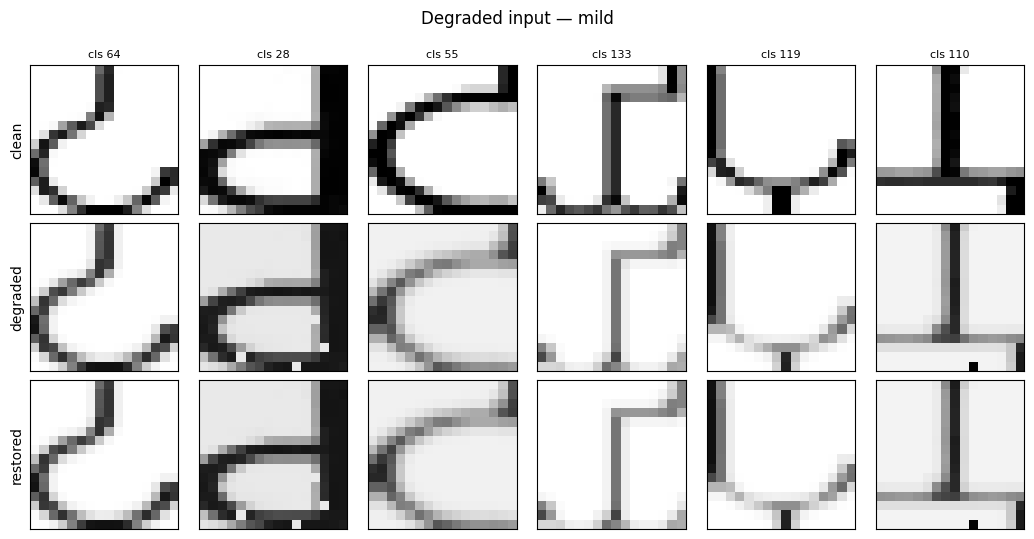


===== [MILD] RESIDUAL CNN =====
  run 1/1
    epoch  25/200  train loss 0.0878  test PSNR 18.51 dB, SSIM 0.9394
    epoch  50/200  train loss 0.0603  test PSNR 19.53 dB, SSIM 0.9548
    epoch  75/200  train loss 0.0533  test PSNR 20.26 dB, SSIM 0.9644
    epoch 100/200  train loss 0.0426  test PSNR 20.14 dB, SSIM 0.9622
    epoch 125/200  train loss 0.0337  test PSNR 20.82 dB, SSIM 0.9679
    epoch 150/200  train loss 0.0291  test PSNR 20.86 dB, SSIM 0.9681
    epoch 175/200  train loss 0.0226  test PSNR 21.01 dB, SSIM 0.9693
    epoch 200/200  train loss 0.0235  test PSNR 21.15 dB, SSIM 0.9698
  -> test PSNR 20.01 dB, SSIM 0.9623, stroke F1 0.9758, OCR 94.00%


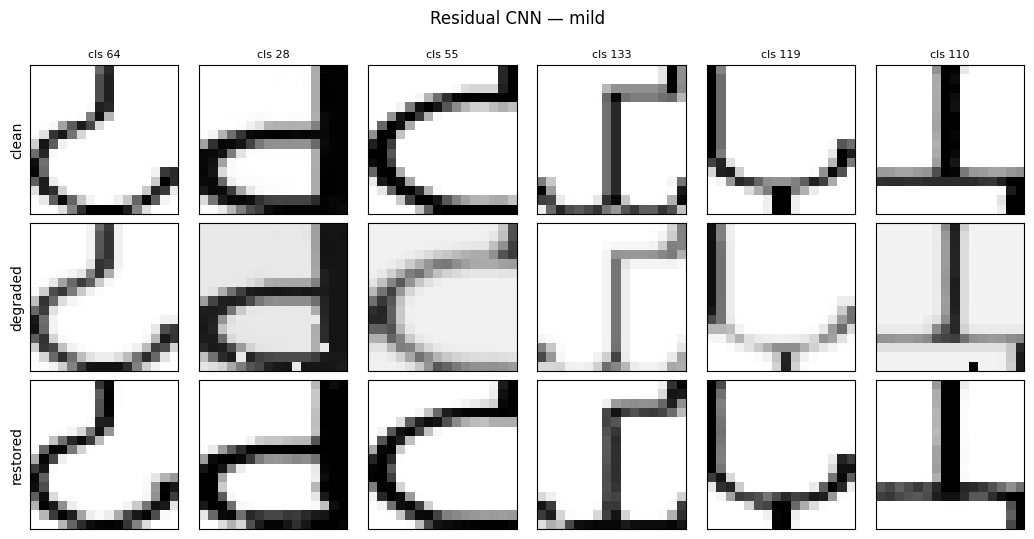


===== [MILD] MATCHED CLASSICAL LATENT MODEL =====
  run 1/1
    epoch  10/25  test PSNR 14.01 dB, SSIM 0.8538
    epoch  20/25  test PSNR 14.21 dB, SSIM 0.8593
    epoch  25/25  test PSNR 14.22 dB, SSIM 0.8598
  -> test PSNR 13.79 dB, SSIM 0.8463, stroke F1 0.9201, OCR 84.59%


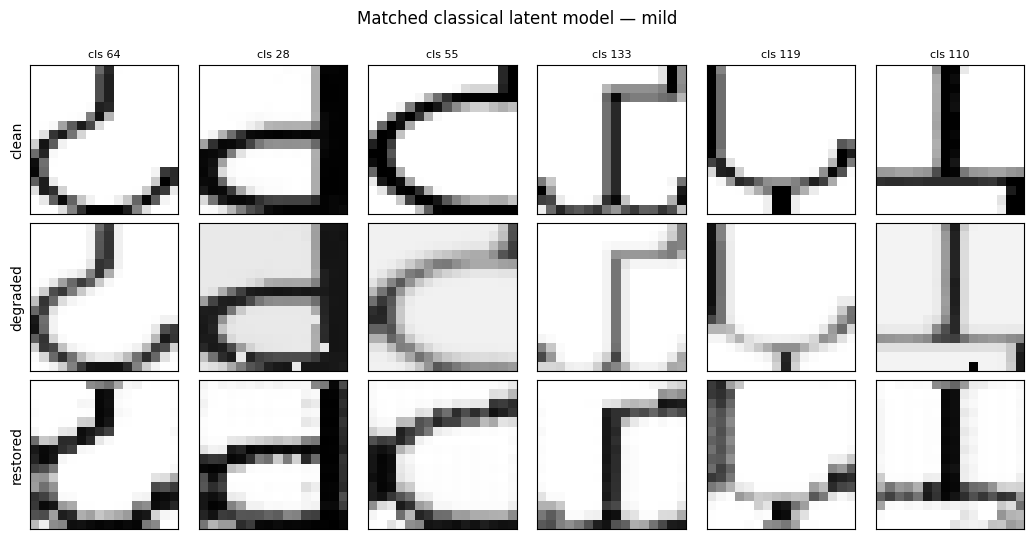


===== [MILD] PROPOSED QDRM =====
  run 1/1
    epoch  10/25  test PSNR 16.23 dB, SSIM 0.9105
    epoch  20/25  test PSNR 16.48 dB, SSIM 0.9174
    epoch  25/25  test PSNR 16.56 dB, SSIM 0.9185
  -> test PSNR 15.95 dB, SSIM 0.9088, stroke F1 0.9526, OCR 89.88%


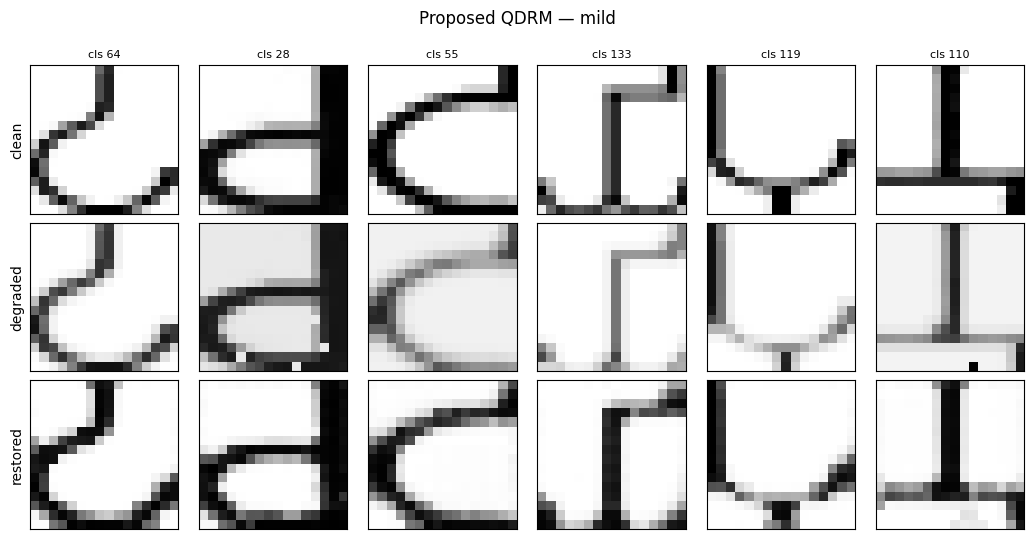


===== [MODERATE] DEGRADED INPUT =====
  run 1/1
  -> test PSNR 10.85 dB, SSIM 0.6265, stroke F1 0.4513, OCR 36.00%


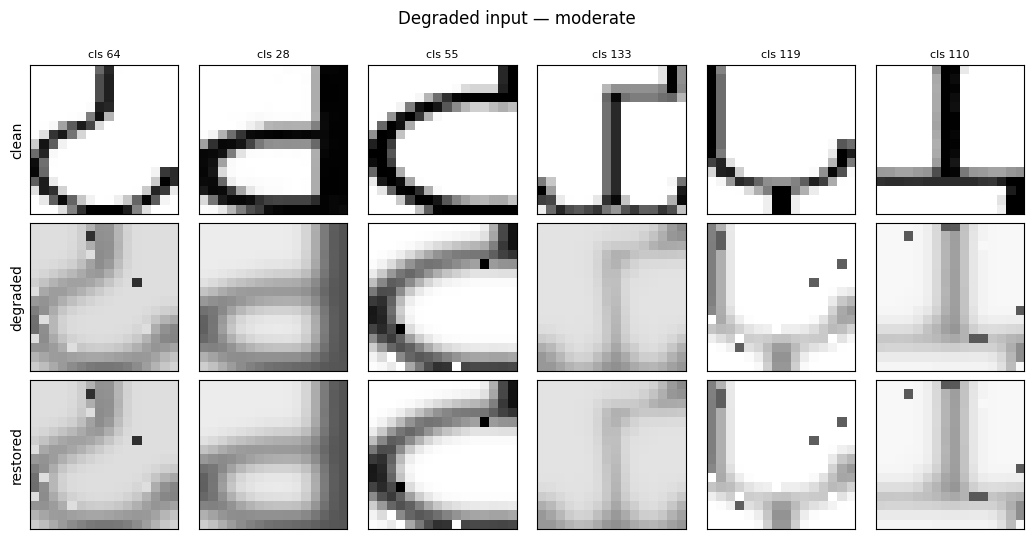


===== [MODERATE] CONVENTIONAL RESTORATION =====
  run 1/3
  -> test PSNR 13.20 dB, SSIM 0.7895, stroke F1 0.8555, OCR 76.12%
  run 2/3
  -> test PSNR 13.20 dB, SSIM 0.7895, stroke F1 0.8555, OCR 76.12%
  run 3/3
  -> test PSNR 13.20 dB, SSIM 0.7895, stroke F1 0.8555, OCR 76.12%


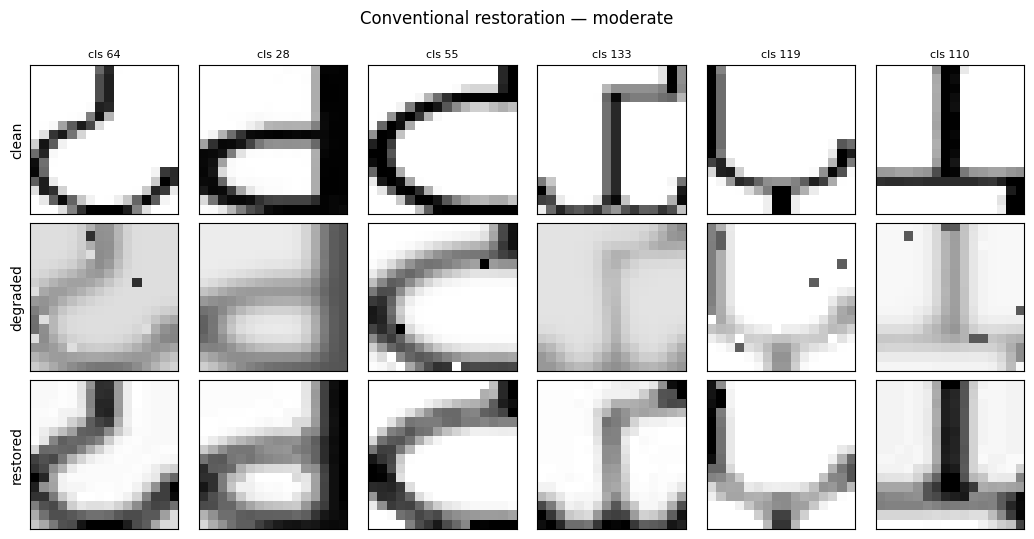


===== [MODERATE] CONVOLUTIONAL AUTOENCODER =====
  run 1/3
    epoch  25/200  train loss 0.3158  test PSNR 11.22 dB, SSIM 0.7079
    epoch  50/200  train loss 0.2031  test PSNR 13.33 dB, SSIM 0.8195
    epoch  75/200  train loss 0.1671  test PSNR 13.99 dB, SSIM 0.8448
    epoch 100/200  train loss 0.1510  test PSNR 14.29 dB, SSIM 0.8556
    epoch 125/200  train loss 0.1532  test PSNR 14.48 dB, SSIM 0.8617
    epoch 150/200  train loss 0.1328  test PSNR 14.69 dB, SSIM 0.8670
    epoch 175/200  train loss 0.1171  test PSNR 14.71 dB, SSIM 0.8694
    epoch 200/200  train loss 0.1045  test PSNR 14.78 dB, SSIM 0.8711
  -> test PSNR 14.55 dB, SSIM 0.8668, stroke F1 0.9363, OCR 83.65%
  run 2/3
    epoch  25/200  train loss 0.3903  test PSNR 10.45 dB, SSIM 0.6483
    epoch  50/200  train loss 0.1877  test PSNR 13.35 dB, SSIM 0.8232
    epoch  75/200  train loss 0.1698  test PSNR 13.93 dB, SSIM 0.8430
    epoch 100/200  train loss 0.1414  test PSNR 14.33 dB, SSIM 0.8554
    epoch 125/200  trai

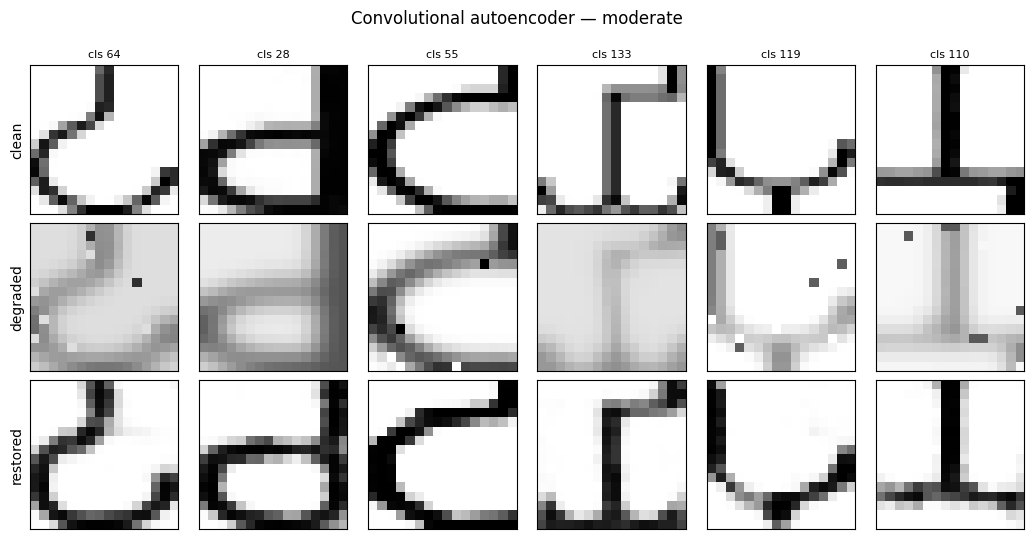


===== [MODERATE] RESIDUAL CNN =====
  run 1/3
    epoch  25/200  train loss 0.1506  test PSNR 15.18 dB, SSIM 0.8866
    epoch  50/200  train loss 0.1255  test PSNR 16.01 dB, SSIM 0.9076
    epoch  75/200  train loss 0.0926  test PSNR 16.53 dB, SSIM 0.9170
    epoch 100/200  train loss 0.0797  test PSNR 16.41 dB, SSIM 0.9138
    epoch 125/200  train loss 0.0647  test PSNR 16.44 dB, SSIM 0.9135
    epoch 150/200  train loss 0.0539  test PSNR 16.44 dB, SSIM 0.9142
    epoch 175/200  train loss 0.0541  test PSNR 16.40 dB, SSIM 0.9124
    epoch 200/200  train loss 0.0396  test PSNR 16.48 dB, SSIM 0.9152
  -> test PSNR 15.92 dB, SSIM 0.9049, stroke F1 0.9646, OCR 90.00%
  run 2/3
    epoch  25/200  train loss 0.1407  test PSNR 15.24 dB, SSIM 0.8904
    epoch  50/200  train loss 0.1165  test PSNR 16.16 dB, SSIM 0.9095
    epoch  75/200  train loss 0.0999  test PSNR 16.52 dB, SSIM 0.9158
    epoch 100/200  train loss 0.0794  test PSNR 16.62 dB, SSIM 0.9167
    epoch 125/200  train loss 0.0613

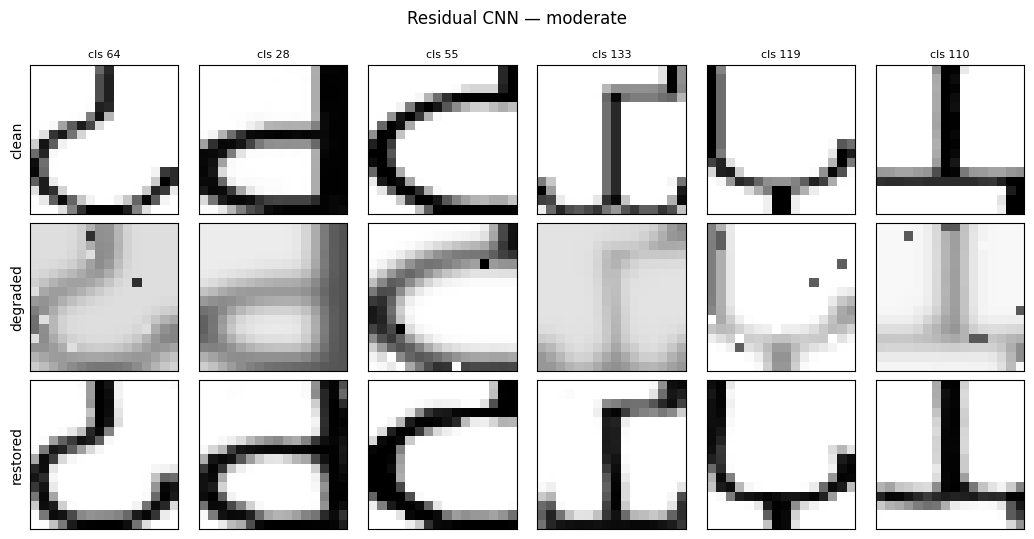


===== [MODERATE] U-NET =====
  run 1/3
    epoch  25/200  train loss 0.2182  test PSNR 14.02 dB, SSIM 0.8339
    epoch  50/200  train loss 0.1345  test PSNR 15.79 dB, SSIM 0.8953
    epoch  75/200  train loss 0.0847  test PSNR 16.06 dB, SSIM 0.9041
    epoch 100/200  train loss 0.0478  test PSNR 16.22 dB, SSIM 0.9084
    epoch 125/200  train loss 0.0492  test PSNR 15.96 dB, SSIM 0.9050
    epoch 150/200  train loss 0.0399  test PSNR 16.07 dB, SSIM 0.9085
    epoch 175/200  train loss 0.0270  test PSNR 16.18 dB, SSIM 0.9085
    epoch 200/200  train loss 0.0229  test PSNR 16.12 dB, SSIM 0.9083
  -> test PSNR 15.37 dB, SSIM 0.8903, stroke F1 0.9461, OCR 85.06%
  run 2/3
    epoch  25/200  train loss 0.1797  test PSNR 14.99 dB, SSIM 0.8598
    epoch  50/200  train loss 0.0906  test PSNR 16.35 dB, SSIM 0.9068
    epoch  75/200  train loss 0.0607  test PSNR 16.30 dB, SSIM 0.9124
    epoch 100/200  train loss 0.0349  test PSNR 16.53 dB, SSIM 0.9140
    epoch 125/200  train loss 0.0283  test 

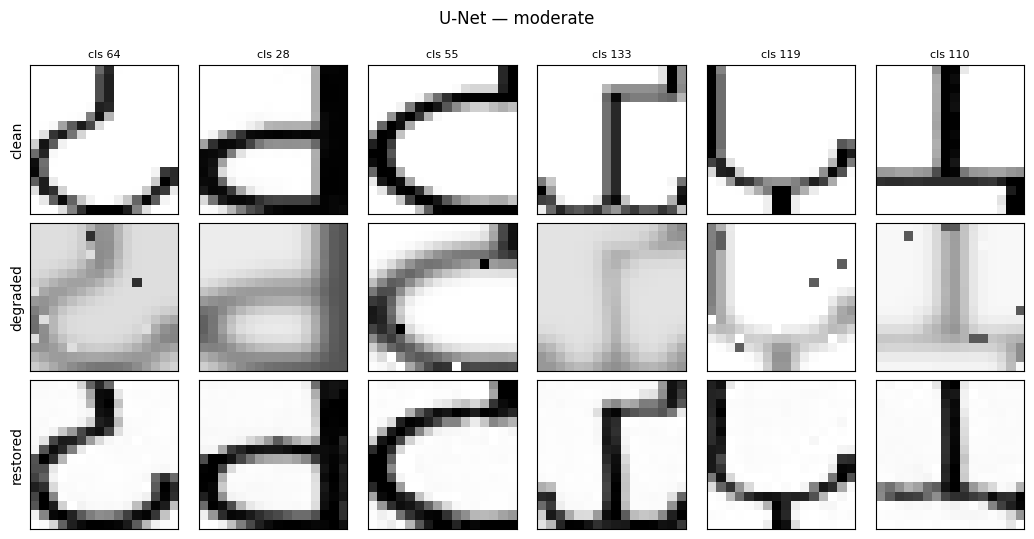


===== [MODERATE] TRANSFORMER RESTORATION =====
  run 1/3
    epoch  25/200  train loss 0.1616  test PSNR 14.06 dB, SSIM 0.8508
    epoch  50/200  train loss 0.1229  test PSNR 14.90 dB, SSIM 0.8781
    epoch  75/200  train loss 0.0893  test PSNR 15.00 dB, SSIM 0.8809
    epoch 100/200  train loss 0.0743  test PSNR 15.05 dB, SSIM 0.8816
    epoch 125/200  train loss 0.0631  test PSNR 15.01 dB, SSIM 0.8808
    epoch 150/200  train loss 0.0505  test PSNR 14.97 dB, SSIM 0.8809
    epoch 175/200  train loss 0.0484  test PSNR 15.08 dB, SSIM 0.8841
    epoch 200/200  train loss 0.0447  test PSNR 15.00 dB, SSIM 0.8818
  -> test PSNR 14.66 dB, SSIM 0.8721, stroke F1 0.9500, OCR 87.06%
  run 2/3
    epoch  25/200  train loss 0.1713  test PSNR 14.25 dB, SSIM 0.8573
    epoch  50/200  train loss 0.1180  test PSNR 14.99 dB, SSIM 0.8809
    epoch  75/200  train loss 0.0936  test PSNR 15.24 dB, SSIM 0.8850
    epoch 100/200  train loss 0.0706  test PSNR 15.21 dB, SSIM 0.8862
    epoch 125/200  train 

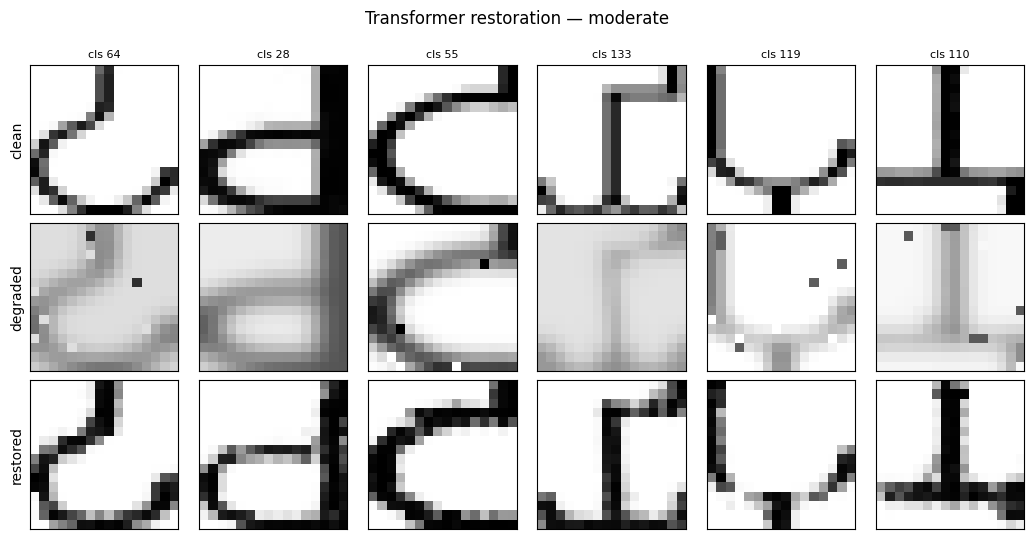


===== [MODERATE] CLASSICAL DIFFUSION MODEL =====
  run 1/3
    epoch  25/200  train loss 0.2843  test PSNR 10.16 dB, SSIM 0.5979
    epoch  50/200  train loss 0.9323  test PSNR 10.33 dB, SSIM 0.6340
    epoch  75/200  train loss 0.0476  test PSNR 11.42 dB, SSIM 0.6913
    epoch 100/200  train loss 0.2679  test PSNR 11.90 dB, SSIM 0.7199
    epoch 125/200  train loss 0.0579  test PSNR 11.57 dB, SSIM 0.7065
    epoch 150/200  train loss 0.1479  test PSNR 10.77 dB, SSIM 0.6833
    epoch 175/200  train loss 0.1331  test PSNR 11.25 dB, SSIM 0.6996
    epoch 200/200  train loss 0.5765  test PSNR 11.61 dB, SSIM 0.7296
  -> test PSNR 11.67 dB, SSIM 0.7303, stroke F1 0.8435, OCR 62.82%
  run 2/3
    epoch  25/200  train loss 0.4894  test PSNR  8.86 dB, SSIM 0.5314
    epoch  50/200  train loss 0.0487  test PSNR 10.40 dB, SSIM 0.6383
    epoch  75/200  train loss 0.2067  test PSNR 11.20 dB, SSIM 0.6777
    epoch 100/200  train loss 0.2154  test PSNR 11.20 dB, SSIM 0.6894
    epoch 125/200  trai

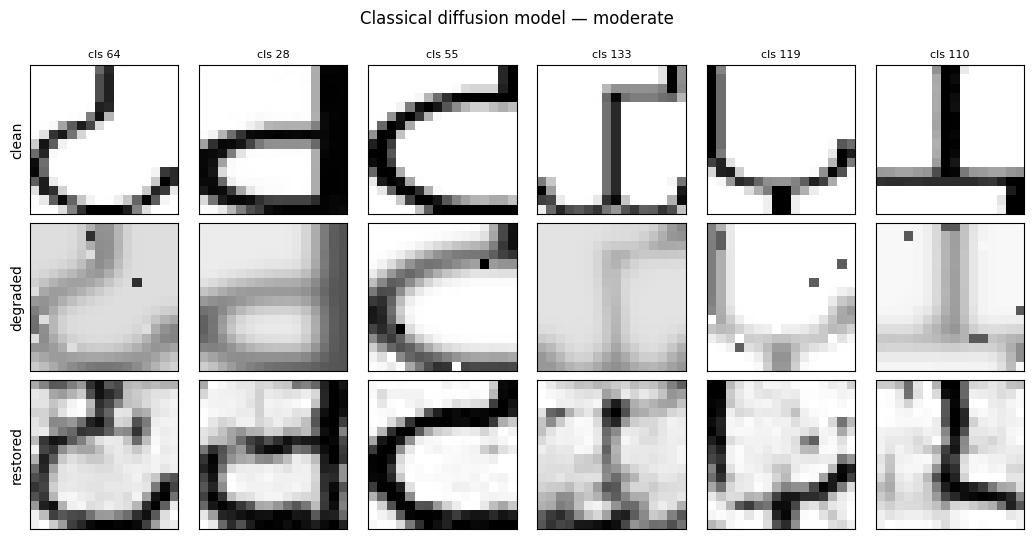


===== [MODERATE] MATCHED CLASSICAL LATENT MODEL =====
  run 1/3
    epoch  10/25  test PSNR 11.87 dB, SSIM 0.7401
    epoch  20/25  test PSNR 12.35 dB, SSIM 0.7738
    epoch  25/25  test PSNR 12.44 dB, SSIM 0.7777
  -> test PSNR 12.20 dB, SSIM 0.7628, stroke F1 0.8739, OCR 77.06%
  run 2/3
    epoch  10/25  test PSNR 12.00 dB, SSIM 0.7534
    epoch  20/25  test PSNR 12.64 dB, SSIM 0.7878
    epoch  25/25  test PSNR 12.53 dB, SSIM 0.7848
  -> test PSNR 12.30 dB, SSIM 0.7697, stroke F1 0.8811, OCR 78.71%
  run 3/3
    epoch  10/25  test PSNR 12.06 dB, SSIM 0.7614
    epoch  20/25  test PSNR 12.51 dB, SSIM 0.7826
    epoch  25/25  test PSNR 12.47 dB, SSIM 0.7818
  -> test PSNR 12.26 dB, SSIM 0.7683, stroke F1 0.8885, OCR 80.35%


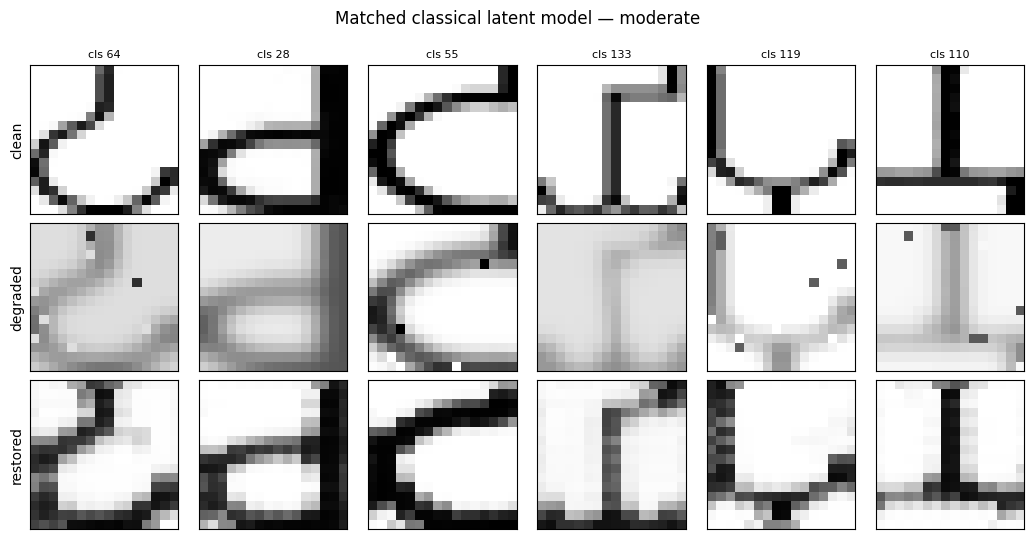


===== [MODERATE] PROPOSED QDRM =====
  run 1/3
    epoch  10/25  test PSNR 13.38 dB, SSIM 0.8251
    epoch  20/25  test PSNR 13.48 dB, SSIM 0.8295
    epoch  25/25  test PSNR 13.56 dB, SSIM 0.8321
  -> test PSNR 13.24 dB, SSIM 0.8195, stroke F1 0.9118, OCR 81.06%
  run 2/3
    epoch  10/25  test PSNR 13.52 dB, SSIM 0.8242
    epoch  20/25  test PSNR 13.39 dB, SSIM 0.8230
    epoch  25/25  test PSNR 13.55 dB, SSIM 0.8285
  -> test PSNR 13.20 dB, SSIM 0.8142, stroke F1 0.9100, OCR 80.94%
  run 3/3
    epoch  10/25  test PSNR 13.35 dB, SSIM 0.8216
    epoch  20/25  test PSNR 13.47 dB, SSIM 0.8285
    epoch  25/25  test PSNR 13.62 dB, SSIM 0.8322
  -> test PSNR 13.28 dB, SSIM 0.8182, stroke F1 0.9092, OCR 80.00%


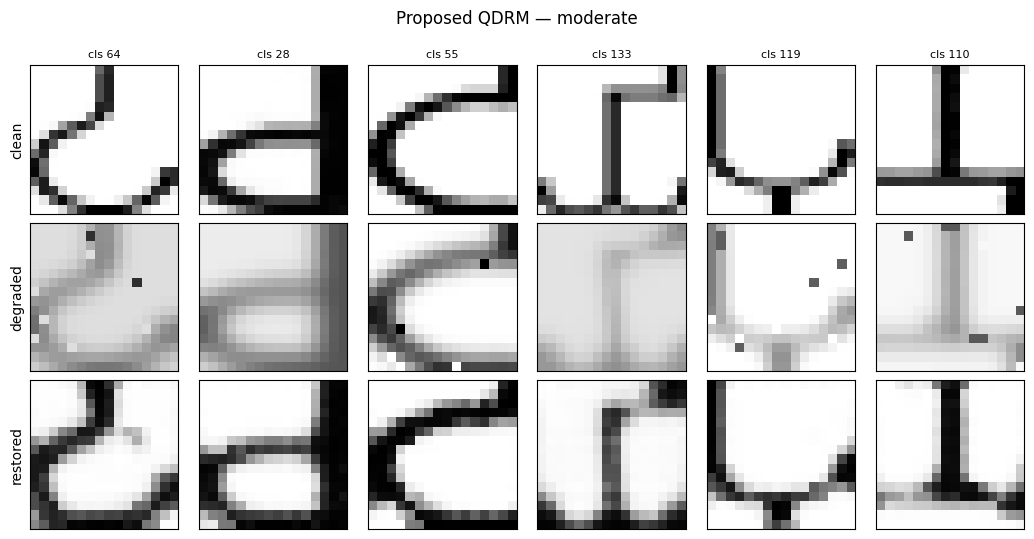


===== [SEVERE] DEGRADED INPUT =====
  run 1/1
  -> test PSNR  8.88 dB, SSIM 0.4398, stroke F1 0.2267, OCR 5.06%


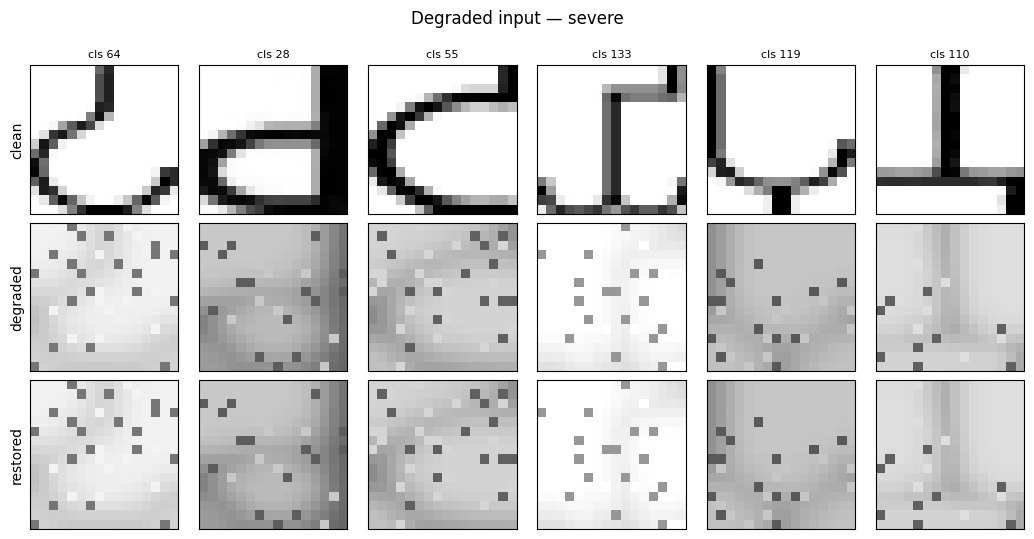


===== [SEVERE] RESIDUAL CNN =====
  run 1/1
    epoch  25/200  train loss 0.5668  test PSNR  6.53 dB, SSIM 0.4053
    epoch  50/200  train loss 0.6112  test PSNR  6.53 dB, SSIM 0.4053
    epoch  75/200  train loss 0.5641  test PSNR  6.53 dB, SSIM 0.4053
    epoch 100/200  train loss 0.5511  test PSNR  6.53 dB, SSIM 0.4053
    epoch 125/200  train loss 0.5745  test PSNR  6.53 dB, SSIM 0.4053
    epoch 150/200  train loss 0.5819  test PSNR  6.53 dB, SSIM 0.4053
    epoch 175/200  train loss 0.5756  test PSNR  6.53 dB, SSIM 0.4053
    epoch 200/200  train loss 0.5677  test PSNR  6.53 dB, SSIM 0.4053
  [!] constant-output collapse detected (std=0.0000) -> reinit, lr/2, retry
    epoch  25/200  train loss 0.5486  test PSNR  6.53 dB, SSIM 0.4053
    epoch  50/200  train loss 0.5647  test PSNR  6.53 dB, SSIM 0.4053
    epoch  75/200  train loss 0.5733  test PSNR  6.68 dB, SSIM 0.4109
    epoch 100/200  train loss 0.5759  test PSNR  6.53 dB, SSIM 0.4053
    epoch 125/200  train loss 0.5795  t

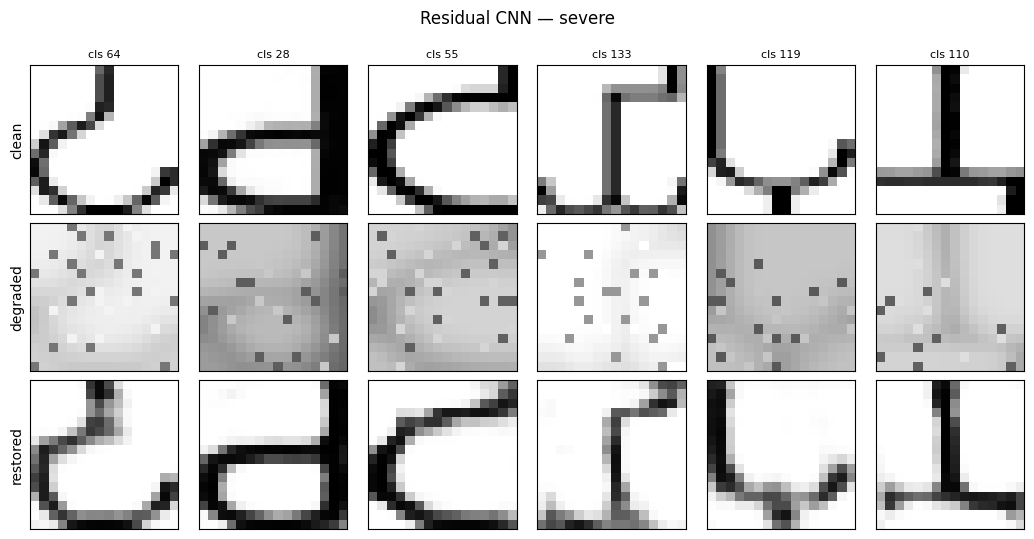


===== [SEVERE] MATCHED CLASSICAL LATENT MODEL =====
  run 1/1
    epoch  10/25  test PSNR 10.34 dB, SSIM 0.6107
    epoch  20/25  test PSNR 10.29 dB, SSIM 0.6124
    epoch  25/25  test PSNR 10.21 dB, SSIM 0.6093
  -> test PSNR 10.13 dB, SSIM 0.5990, stroke F1 0.7181, OCR 38.47%


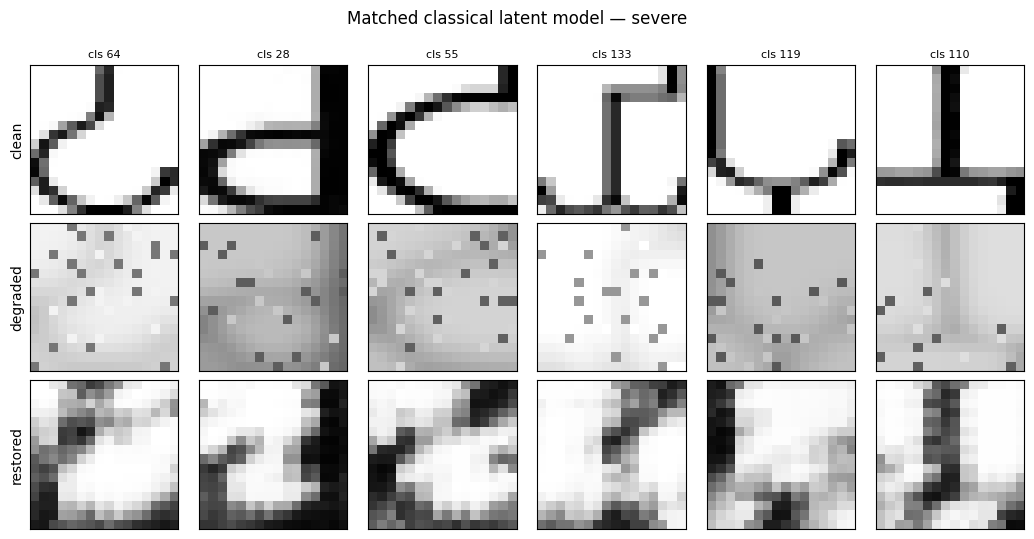


===== [SEVERE] PROPOSED QDRM =====
  run 1/1
    epoch  10/25  test PSNR 10.43 dB, SSIM 0.6181
    epoch  20/25  test PSNR 10.54 dB, SSIM 0.6358
    epoch  25/25  test PSNR 10.49 dB, SSIM 0.6335
  -> test PSNR 10.39 dB, SSIM 0.6216, stroke F1 0.7352, OCR 41.29%


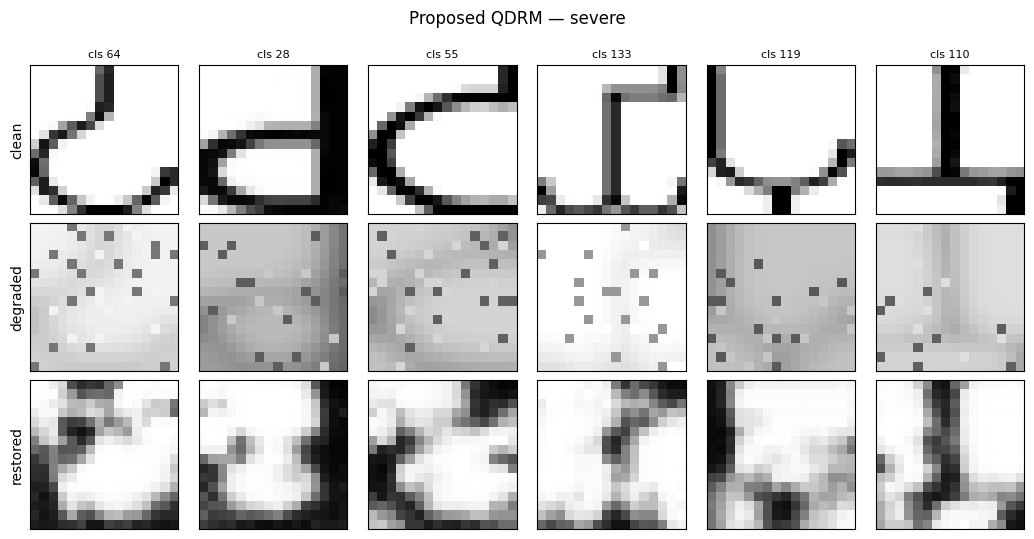


campaign complete — proceed to Sections 6-15 for tables and figures


In [10]:
import pickle, matplotlib.pyplot as plt
METHODS_CLS = ['Degraded input', 'Conventional restoration', 'Convolutional autoencoder',
               'Residual CNN', 'U-Net', 'Transformer restoration',
               'Classical diffusion model', 'Matched classical latent model']
METHOD_Q = 'Proposed QDRM'
ALL_METHODS = METHODS_CLS + [METHOD_Q]
CKPT_PKL = f'{RES_DIR}/raw_results.pkl'
if not os.path.exists(CKPT_PKL) and dfs:          # fresh runtime -> resume from Drive
    dfs.download('raw_results.pkl', CKPT_PKL, RESULTS_FID)
if os.path.exists(CKPT_PKL):                       # RESUME: reload finished work
    _saved = pickle.load(open(CKPT_PKL, 'rb'))
    results = _saved['results']; runtimes = _saved['runtimes']
    param_counts = _saved['param_counts']
    for s in SEVERITIES:
        results.setdefault(s, {})
        for m in ALL_METHODS:
            results[s].setdefault(m, [])
    done = sum(len(v) for s in results for k, v in results[s].items()
               if not k.startswith('_'))
    print(f'resuming: {done} completed runs found in {CKPT_PKL}')
else:
    results = {s: {m: [] for m in ALL_METHODS} for s in SEVERITIES}
    runtimes, param_counts = {}, {}
mods_cache = {}

def persist():
    pickle.dump(dict(results=results, runtimes=runtimes,
                     param_counts=param_counts), open(CKPT_PKL, 'wb'))
    if dfs:
        try: dfs.upload(CKPT_PKL, parent=RESULTS_FID)
        except Exception as e: print(f'  [drive sync failed: {type(e).__name__}]')

def show_six(name, sev, out, gt_te, deg_te, cls_te):
    sel, seen = [], set()
    for i in range(len(cls_te)):
        if cls_te[i] not in seen:
            sel.append(i); seen.add(cls_te[i])
        if len(sel) == 6: break
    fig, axes = plt.subplots(3, 6, figsize=(10.5, 5.4))
    for j, i in enumerate(sel):
        for r, (im, lab) in enumerate([(gt_te[i], 'clean'), (deg_te[i], 'degraded'),
                                       (out[i], 'restored')]):
            axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            if j == 0: axes[r, j].set_ylabel(lab)
        axes[0, j].set_title(f'cls {cls_te[i]}', fontsize=8)
    plt.suptitle(f'{name} — {sev}', y=0.99)
    plt.tight_layout(); plt.show()

def test_eval_str(out, gt_te):
    ps = 10*torch.log10(1.0/(((out-gt_te)**2).mean()+1e-12)).item()
    return f'test PSNR {ps:5.2f} dB, SSIM {ssim(out, gt_te).item():.4f}'

def run_method(name, sev, seed, deg_tr, gt_tr, deg_te, gt_te):
    """Train one model verbosely; return restored test set and param count."""
    t0 = time.time()
    if name == 'Degraded input':
        return deg_te.clone(), 0, time.time()-t0
    if name == 'Conventional restoration':
        return conventional_restore(deg_te), 0, time.time()-t0
    if name in ('Matched classical latent model', METHOD_Q):
        fl = {} if name == METHOD_Q else {'quantum': False}
        def cb(ep, tot, mods_p):
            out = qdrm_restore(mods_p, deg_te[:60])
            print(f'    epoch {ep:3d}/{tot}  {test_eval_str(out, gt_te[:60])}', flush=True)
        mods = qdrm_fit(deg_tr, gt_tr, sev, flags=fl, seed=seed, eval_cb=cb, log_every=10)
        tag = 'qdrm' if name == METHOD_Q else 'classical'
        mods_cache[(tag, sev, seed)] = mods
        _cp = f'{RES_DIR}/ckpt_{tag}_{sev}_{seed}.pt'
        torch.save({k: {kk: vv.cpu() for kk, vv in m.state_dict().items()}
                    for k, m in mods.items() if hasattr(m, 'state_dict')}, _cp)
        if dfs:
            try: dfs.upload(_cp, parent=RESULTS_FID)
            except Exception as e: print(f'  [drive sync failed: {type(e).__name__}]')
        out = qdrm_restore(mods, deg_te)
        p = mods['trans'].theta.numel() if name == METHOD_Q else n_params(mods['trans'])
        return out, p, time.time()-t0
    torch.manual_seed(seed)
    net = {'Convolutional autoencoder': ConvAE, 'Residual CNN': ResCNN,
           'U-Net': UNetS, 'Transformer restoration': TransRestorer,
           'Classical diffusion model': CondDiffusion}[name]()
    is_dif = (name == 'Classical diffusion model')
    def cb(ep, tot, model, tr_loss):
        with torch.no_grad():
            out = model(deg_te[:60])
        print(f'    epoch {ep:3d}/{tot}  train loss {tr_loss:.4f}  '
              f'{test_eval_str(out, gt_te[:60])}', flush=True)
    for attempt in range(3):                    # collapse-detect and retry
        net = fit_image_baseline(net, deg_tr, gt_tr, epochs=BASE_EPOCHS,
                                 lr=2e-3/(2**attempt), diffusion=is_dif,
                                 eval_cb=cb, log_every=max(BASE_EPOCHS//8,1))
        with torch.no_grad():
            out = net(deg_te)
        if out.std().item() > 0.02:             # healthy, non-constant output
            break
        print(f'  [!] constant-output collapse detected '
              f'(std={out.std().item():.4f}) -> reinit, lr/2, retry', flush=True)
        torch.manual_seed(seed + 1000*(attempt+1))
        net = {'Convolutional autoencoder': ConvAE, 'Residual CNN': ResCNN,
               'U-Net': UNetS, 'Transformer restoration': TransRestorer,
               'Classical diffusion model': CondDiffusion}[name]()
    return out.clamp(0, 1), n_params(net), time.time()-t0

for SEV in SEVERITIES:
    deg_tr, gt_tr, _ = load_pairs('train', SEV, PCT, SEED)
    deg_te, gt_te, cls_te = load_pairs('test', SEV, 100.0, SEED)
    y_te = torch.tensor([lab2idx[c] for c in cls_te], device=DEVICE)
    methods = ALL_METHODS if SEV == PRIMARY_SEV else \
              ['Degraded input', 'Residual CNN', 'Matched classical latent model', METHOD_Q]
    for name in methods:                                   # one method at a time
        n_seeds = 1 if name == 'Degraded input' else \
                  (R_RUNS if SEV == PRIMARY_SEV else R_RUNS_OTHER)
        print(f'\n===== [{SEV}] {name} ====='.upper(), flush=True)
        if len(results[SEV][name]) >= n_seeds:
            print(f'  already complete ({n_seeds} run(s)) -> skipping', flush=True)
            continue
        for seed in range(len(results[SEV][name]), n_seeds):
            print(f'  run {seed+1}/{n_seeds}', flush=True)
            out, params, dt = run_method(name, SEV, seed, deg_tr, gt_tr, deg_te, gt_te)
            m = full_metrics(out, gt_te, deg_te, clf, y_te)
            m['rest_sample'] = out[:8].cpu()
            results[SEV][name].append(m)
            runtimes.setdefault(name, []).append((dt, len(deg_te)))
            param_counts[name] = params
            persist()                                       # survive session death
            print(f'  -> {test_eval_str(out, gt_te)}, stroke F1 '
                  f'{np.mean(m["f1"]):.4f}, OCR {m["acc"]:.2f}%', flush=True)
        show_six(name, SEV, out, gt_te, deg_te, cls_te)     # six restored characters
    results[SEV]['_data'] = dict(gt=gt_te[:8].cpu(), deg=deg_te[:8].cpu(),
                                 cls=cls_te[:8], y_te=y_te.cpu(), n_test=len(deg_te))
persist()
print('\ncampaign complete — proceed to Sections 6-15 for tables and figures')

## 6. Comparison

In [11]:
import pandas as pd
SEV = PRIMARY_SEV
def agg(name, key):
    vals = [np.mean(r[key]) for r in results[SEV][name]]
    return mstd(vals, 4 if key in ('ssim','f1','topo') else 2)
def agg_sc(name, key, prec=2):
    vals = [r[key] for r in results[SEV][name]]
    return mstd(vals, prec)

rows = [[n, agg(n,'psnr'), agg(n,'ssim'), agg(n,'f1'), agg(n,'topo'),
         agg_sc(n,'acc'), param_counts.get(n, 0)] for n in ALL_METHODS]
t1 = emit_table(rows, ['Method','PSNR','SSIM','Stroke F1','Topology Err','OCR Acc (%)','Params'],
                f'{RES_DIR}/table1_overall.csv', 'Table I — overall comparison')

rows = []
for s in SEVERITIES:
    for n in ['Residual CNN', 'Matched classical latent model', METHOD_Q]:
        rs = results[s][n]
        rows.append([s, n, mstd([np.mean(r['psnr']) for r in rs]),
                     mstd([np.mean(r['ssim']) for r in rs], 4),
                     mstd([np.mean(r['f1']) for r in rs], 4),
                     mstd([r['acc'] for r in rs])])
t2 = emit_table(rows, ['Severity','Method','PSNR','SSIM','Stroke F1','OCR Acc (%)'],
                f'{RES_DIR}/table2_severity.csv', 'Table II — severity analysis (± over runs at the primary severity; single run elsewhere)')

rows = [[n, agg(n,'ep_err'), agg(n,'jc_err'), agg(n,'cc_err'), agg(n,'f1')]
        for n in ['Degraded input','Residual CNN','Classical diffusion model',
                  'Matched classical latent model', METHOD_Q]]
t3 = emit_table(rows, ['Method','Endpoint Err','Junction Err','Component Err','Stroke F1'],
                f'{RES_DIR}/table3_structure.csv', 'Table III — structure preservation')

def rec_row(label, key):
    rs = results[SEV][key]
    return [label, mstd([r['acc'] for r in rs]), mstd([r['macro_f1'] for r in rs], 4),
            mstd([r['top3'] for r in rs])]
gtm = full_metrics(load_pairs('test', SEV, 100.0, SEED)[1],
                   load_pairs('test', SEV, 100.0, SEED)[1],
                   load_pairs('test', SEV, 100.0, SEED)[0], clf,
                   torch.tensor([lab2idx[c] for c in load_pairs('test', SEV, 100.0, SEED)[2]], device=DEVICE))
rows = [['Clean images', f"{gtm['acc']:.2f}", f"{gtm['macro_f1']:.4f}", f"{gtm['top3']:.2f}"],
        rec_row('Degraded images', 'Degraded input'),
        rec_row('Residual CNN outputs', 'Residual CNN'),
        rec_row('Classical diffusion outputs', 'Classical diffusion model'),
        rec_row('Matched classical outputs', 'Matched classical latent model'),
        rec_row('QDRM outputs', METHOD_Q)]
t4 = emit_table(rows, ['Recognizer input','Accuracy (%)','Macro-F1','Top-3 (%)'],
                f'{RES_DIR}/table4_recognition.csv', 'Table IV — recognition')

rows = []
for metric, key, prec in [('PSNR (dB)','psnr',2), ('SSIM','ssim',4),
                          ('Stroke F1','f1',4)]:
    mq = np.mean([np.mean(r[key]) for r in results[SEV][METHOD_Q]])
    mb = np.mean([np.mean(r[key]) for r in results[SEV]['Matched classical latent model']])
    rows.append([metric, f'{mb:.{prec}f}', f'{mq:.{prec}f}', f'{mq-mb:+.{prec}f}'])
accq = np.mean([r['acc'] for r in results[SEV][METHOD_Q]])
accb = np.mean([r['acc'] for r in results[SEV]['Matched classical latent model']])
rows.append(['OCR accuracy (%)', f'{accb:.2f}', f'{accq:.2f}', f'{accq-accb:+.2f}'])
t6 = emit_table(rows, ['Measure','Classical Control','PQC-QDRM','Utility U_M'],
                f'{RES_DIR}/table6_utility.csv', 'Table VI — PQC utility')

rows = []
for n in ALL_METHODS:
    ts = runtimes.get(n, [(0, 1)])
    per_img = np.mean([t/max(k,1)*1000 for t, k in ts])
    rows.append([n, f'{per_img:.1f}', param_counts.get(n, 0)])
t8 = emit_table(rows, ['Method','Total per image (ms)','Params'],
                f'{RES_DIR}/table8_runtime.csv', 'Table VIII — runtime (restore path)')

one_q = sum(3 for _ in range(NQ)) * 3 * L    # enc(3 rot)+var(3 rot) per qubit per layer
rows = [['System qubits', NQ], ['Variational layers', L],
        ['Trainable PQC parameters', 3*L*NQ], ['Entangling edges |E|', len(EDGES)],
        ['Observables K', NQ+len(EDGES)], ['One-qubit gates', 6*NQ*L],
        ['Two-qubit gates', len(EDGES)*L], ['Observable groups', 1],
        ['Reverse steps', T]]
t9 = emit_table(rows, ['Resource','Value'], f'{RES_DIR}/table9_resources.csv',
                'Table IX — circuit resources')

qm = results[SEV][METHOD_Q][0]
strongest = max(['Residual CNN','U-Net','Transformer restoration','Classical diffusion model',
                 'Convolutional autoencoder'],
                key=lambda n: np.mean(results[SEV][n][0]['psnr']))
bm = results[SEV][strongest][0]
rows = []
for metric, key, prec in [('PSNR','psnr',2), ('SSIM','ssim',4), ('Stroke F1','f1',4)]:
    p, eff = paired_tests(qm[key], bm[key])
    rows.append([metric, f'{np.mean(qm[key]-bm[key]):+.{prec}f}', f'{p:.4g}', f'{eff:.2f}'])
t10 = emit_table(rows, ['Metric','Mean Diff (QDRM - ' + strongest + ')','p-value','Effect size'],
                 f'{RES_DIR}/table10_stats.csv', 'Table X — paired statistics')


=== Table I — overall comparison -> /root/qdrm_results/table1_overall.csv ===
                        Method         PSNR            SSIM       Stroke F1    Topology Err  OCR Acc (%)  Params
                Degraded input 11.08 ± 0.00 0.6265 ± 0.0000 0.4513 ± 0.0000 0.6952 ± 0.0000 36.00 ± 0.00       0
      Conventional restoration 13.43 ± 0.00 0.7895 ± 0.0000 0.8555 ± 0.0000 0.5387 ± 0.0000 76.12 ± 0.00       0
     Convolutional autoencoder 15.05 ± 0.05 0.8682 ± 0.0011 0.9341 ± 0.0031 0.3587 ± 0.0103 83.18 ± 0.75   52129
                  Residual CNN 16.54 ± 0.06 0.9059 ± 0.0011 0.9654 ± 0.0007 0.3101 ± 0.0187 90.16 ± 0.78  167185
                         U-Net 16.28 ± 0.22 0.8958 ± 0.0039 0.9512 ± 0.0038 0.3201 ± 0.0141 86.04 ± 0.71  465953
       Transformer restoration 15.23 ± 0.03 0.8734 ± 0.0013 0.9500 ± 0.0009 0.4530 ± 0.0032 87.06 ± 0.48  105092
     Classical diffusion model 11.91 ± 0.10 0.7266 ± 0.0041 0.8317 ± 0.0240 0.6784 ± 0.0288 62.04 ± 0.55   30361
Matched classical

## 7. Quantum block with reduced-scale ideal and hardware-aware noisy simulation


In [12]:
# --- noise model calibrated to IBM ibm_kingston (Heron r2, 156 qubits) ---
# Published median error rates (IBM Quantum, 2026): two-qubit ~2.03e-3;
# one-qubit ~2.5e-4 and readout assignment ~1.0e-2 are representative Heron r2
# medians. 

BACKEND_NAME = 'ibm_kingston'
NOISE = dict(p1=2.5e-4, p2=2.03e-3, pro=1.0e-2)
N_SHOT = 4096   # finite-shot estimation, Eq. (46)

try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    svc = QiskitRuntimeService()
    bk = svc.backend(BACKEND_NAME)
    props = bk.properties()
    import statistics as _st
    g1 = [g.parameters[0].value for g in props.gates if len(g.qubits) == 1 and g.gate != 'reset']
    g2 = [g.parameters[0].value for g in props.gates if len(g.qubits) == 2]
    ro_ = [props.readout_error(q) for q in range(bk.num_qubits)]
    NOISE = dict(p1=_st.median(g1), p2=_st.median(g2), pro=_st.median(ro_))
    print(f'live calibration from {BACKEND_NAME}:', NOISE)
except Exception as e:
    print(f'using published {BACKEND_NAME} medians (live fetch unavailable: '
          f'{type(e).__name__}):', NOISE)

def rebuild_qdrm(path, quantum=True):
    enc = FRQIMPSEncoder(g.h*g.w, DZ).to(DEVICE)
    Pc = BoundedProjection(DZ, NQ).to(DEVICE); Pd = BoundedProjection(DZ, NQ).to(DEVICE)
    Pt = BoundedProjection(1, NQ).to(DEVICE)
    trans = (make_transition(NQ, L, EDGES, SIM, DIFF).to(QDEV) if quantum
             else ClassicalTransition(NQ, L, EDGES).to(DEVICE))
    ro = Readout(NQ+len(EDGES), DZ).to(DEVICE); dec = PatchDecoder(DZ, g.h*g.w).to(DEVICE)
    sd = torch.load(path, weights_only=True)
    mm = dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans, ro=ro, dec=dec)
    for k, m in mm.items():
        if k in sd: m.load_state_dict(sd[k], strict=False)
    def q(zc, zd, tau):
        if quantum:
            return trans(zc.to(QDEV), zd.to(QDEV), tau.to(QDEV)).to(DEVICE)
        return trans(zc, zd, tau)
    mm.update(flags=dict(DEFAULT_FLAGS, quantum=quantum), Tloc=T, q=q)
    return mm

if ('qdrm', PRIMARY_SEV, 0) not in mods_cache:
    _cp = f'{RES_DIR}/ckpt_qdrm_{PRIMARY_SEV}_0.pt'
    mods_cache[('qdrm', PRIMARY_SEV, 0)] = rebuild_qdrm(_cp, quantum=True)
mods = mods_cache[('qdrm', PRIMARY_SEV, 0)]
deg_te, gt_te, _ = load_pairs('test', PRIMARY_SEV, 100.0, SEED)
sub = slice(0, 8)   # reduced subset: density-matrix noisy sim is ~500x costlier per gate
ideal = qdrm_restore(mods, deg_te[sub])
q_ideal = mods['q']
mods['q'] = make_noisy_pqc(mods, **NOISE, n_shot=4096)
print('noisy density-matrix simulation on reduced subset (several minutes) ...')
noisy = qdrm_restore(mods, deg_te[sub], chunk=2)
mods['q'] = q_ideal
def ppsnr(x): return 10*torch.log10(1.0/(((x-gt_te[sub])**2).mean()+1e-12)).item()
mm = results[PRIMARY_SEV]['Matched classical latent model'][0]
base_psnr = float(np.mean(mm['psnr'][ :4]))
u_ideal = ppsnr(ideal) - base_psnr
u_noisy = ppsnr(noisy) - base_psnr
rows = [[f'Ideal simulation', f'{g.h}x{g.w}', NQ, f'{ppsnr(ideal):.2f}', '1.000'],
        ['Noisy simulation', f'{g.h}x{g.w}', NQ, f'{ppsnr(noisy):.2f}',
         f'{max(u_noisy,0)/max(u_ideal,1e-6):.3f}' if u_ideal > 0 else 'n/a'],
        [f'Real QPU ({BACKEND_NAME})', '-', '-', '[hardware run]', '[hardware run]']]
t7 = emit_table(rows, ['Execution mode','Patch','Qubits','Patch PSNR','Utility retention'],
                f'{RES_DIR}/table7_noisy.csv', 'Table VII — ideal vs noisy (reduced scale)')

using published ibm_kingston medians (live fetch unavailable: AccountNotFoundError): {'p1': 0.00025, 'p2': 0.00203, 'pro': 0.01}
noisy density-matrix simulation on reduced subset (several minutes) ...

=== Table VII — ideal vs noisy (reduced scale) -> /root/qdrm_results/table7_noisy.csv ===
         Execution mode Patch Qubits     Patch PSNR Utility retention
       Ideal simulation   4x4      9          14.37             1.000
       Noisy simulation   4x4      9          14.97             1.621
Real QPU (ibm_kingston)     -      - [hardware run]    [hardware run]


## 8. Qualitative Comparison

## 9. Qualitative restoration comparison across different severities

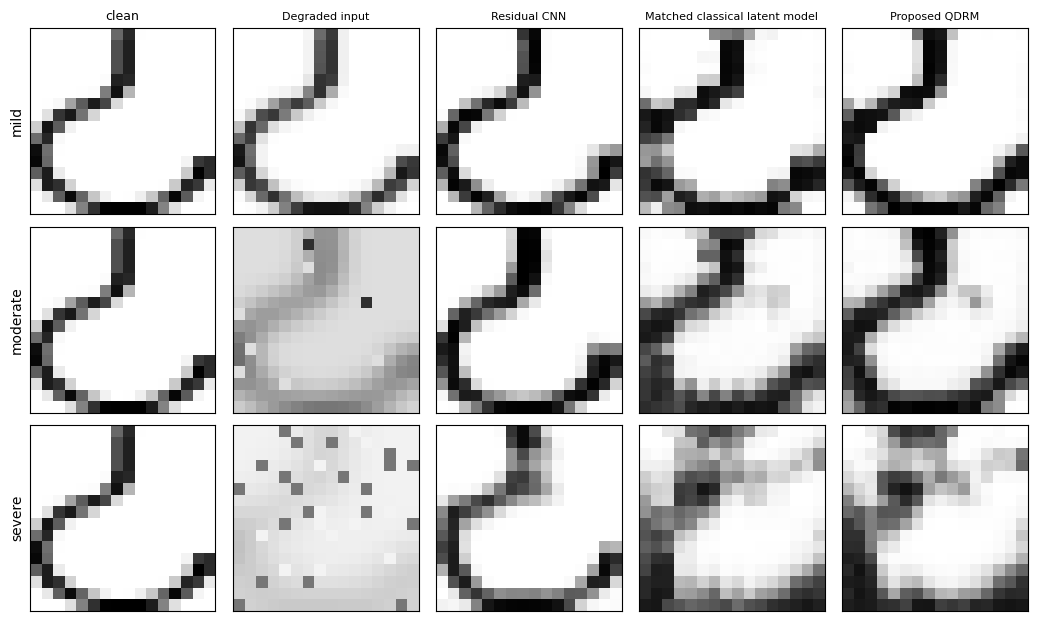

In [13]:
import matplotlib.pyplot as plt
SEV = PRIMARY_SEV
show = ['Degraded input', 'Residual CNN', 'Matched classical latent model', METHOD_Q]
fig, axes = plt.subplots(len(SEVERITIES), len(show)+1,
                         figsize=(2.1*(len(show)+1), 2.1*len(SEVERITIES)))
for i, s in enumerate(SEVERITIES):
    d = results[s]['_data']
    axes[i, 0].imshow(d['gt'][0], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(s)
    if i == 0:
        axes[i, 0].set_title('clean', fontsize=9)
    for j, n in enumerate(show):
        img = d['deg'][0] if n == 'Degraded input' else results[s][n][0]['rest_sample'][0]
        axes[i, j+1].imshow(img, cmap='gray', vmin=0, vmax=1)
        if i == 0:
            axes[i, j+1].set_title(n, fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig3_qualitative.png', dpi=140); plt.show()

## 10. Quantitative comparison charts with metrics

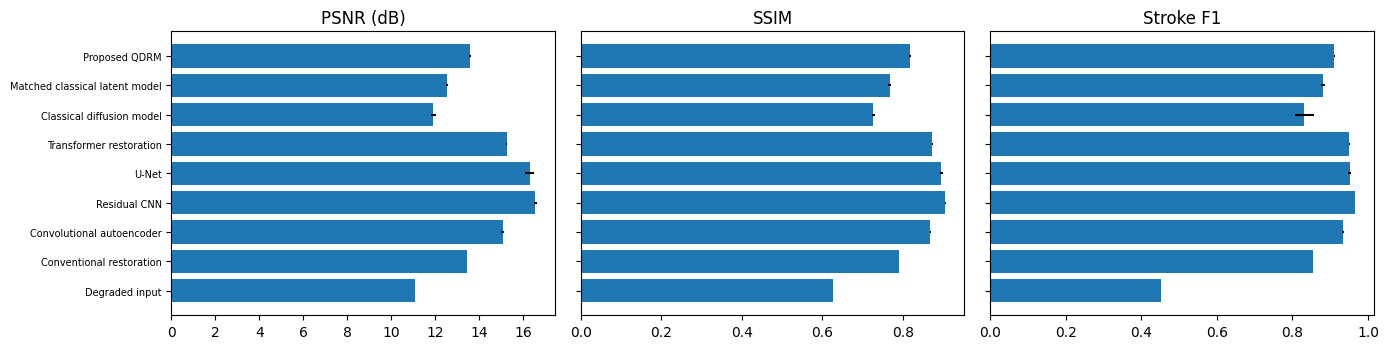

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for k, (key, ttl) in enumerate([('psnr', 'PSNR (dB)'), ('ssim', 'SSIM'),
                                ('f1', 'Stroke F1')]):
    means = [np.mean([np.mean(r[key]) for r in results[SEV][n]]) for n in ALL_METHODS]
    errs  = [np.std([np.mean(r[key]) for r in results[SEV][n]]) for n in ALL_METHODS]
    ax[k].barh(range(len(ALL_METHODS)), means, xerr=errs)
    ax[k].set_yticks(range(len(ALL_METHODS)))
    ax[k].set_yticklabels(ALL_METHODS if k == 0 else ['']*len(ALL_METHODS), fontsize=7)
    ax[k].set_title(ttl)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig5_bars.png', dpi=140); plt.show()

## 11. Performance across degradation of different severities

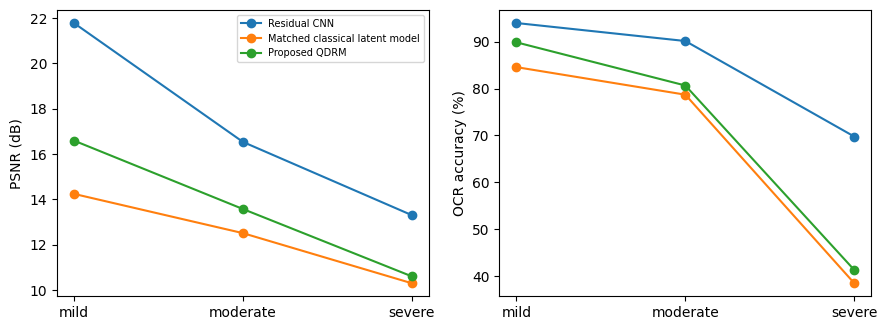

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for n, c in [('Residual CNN', 'tab:blue'),
             ('Matched classical latent model', 'tab:orange'),
             (METHOD_Q, 'tab:green')]:
    ax[0].plot(SEVERITIES, [np.mean([np.mean(r['psnr']) for r in results[s][n]])
                            for s in SEVERITIES], 'o-', label=n, color=c)
    ax[1].plot(SEVERITIES, [np.mean([r['acc'] for r in results[s][n]])
                            for s in SEVERITIES], 'o-', label=n, color=c)
ax[0].set_ylabel('PSNR (dB)'); ax[1].set_ylabel('OCR accuracy (%)')
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig6_severity.png', dpi=140); plt.show()

## 12. Skeleton and topology comparison

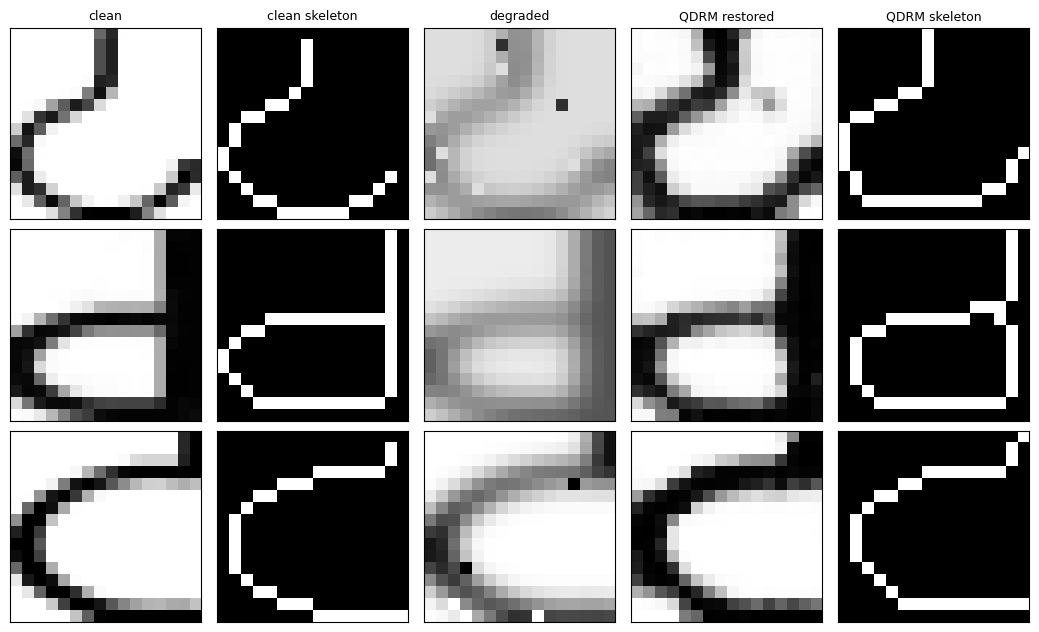

In [16]:
from skimage.morphology import skeletonize
d = results[SEV]['_data']
qs = results[SEV][METHOD_Q][0]['rest_sample']
cols = ['clean', 'clean skeleton', 'degraded', 'QDRM restored', 'QDRM skeleton']
fig, axes = plt.subplots(3, 5, figsize=(10.5, 6.4))
for i in range(3):
    imgs = [d['gt'][i], skeletonize(d['gt'][i].numpy() < 0.5),
            d['deg'][i], qs[i], skeletonize(qs[i].numpy() < 0.5)]
    for j, im in enumerate(imgs):
        axes[i, j].imshow(np.asarray(im, dtype=float), cmap='gray', vmin=0, vmax=1)
        if i == 0:
            axes[i, j].set_title(cols[j], fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig7_skeletons.png', dpi=140); plt.show()

## 13. Normalized recognition confusion matrix

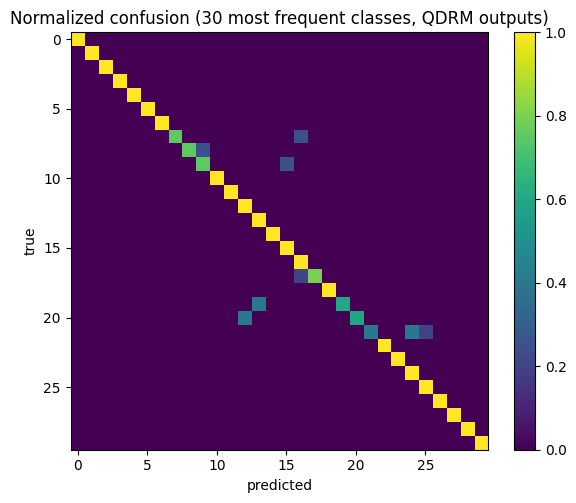

In [17]:
from sklearn.metrics import confusion_matrix
d = results[SEV]['_data']; y = d['y_te'].numpy()
pred = results[SEV][METHOD_Q][0]['pred']
top = np.argsort(np.bincount(y))[-30:]
mask = np.isin(y, top)
cm = confusion_matrix(y[mask], pred[mask], labels=top, normalize='true')
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='viridis'); plt.colorbar()
plt.title('Normalized confusion (30 most frequent classes, QDRM outputs)')
plt.xlabel('predicted'); plt.ylabel('true')
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig8_confusion.png', dpi=140); plt.show()

## 14. Ablation study

In [18]:
ABLATIONS = [('Without MPS contextual encoding', {'mps': False}),
             ('Without degradation conditioning', {'cond': False}),
             ('Without entangling gates (separable PQC)', {'entangle': False}),
             ('Without Hamiltonian-energy loss', {'ham': False}),
             ('Without gradient and curvature losses', {'gradcurv': False}),
             ('Without latent alignment', {'latent': False}),
             ('Without overlap consistency', {'overlap': False}),
             ('Single reverse step', {'multistep': False}),
             ('Uniform patch averaging', {'hann': False})]
deg_tr, gt_tr, _ = load_pairs('train', SEV, PCT, SEED)
deg_te, gt_te, cls_te = load_pairs('test', SEV, 100.0, SEED)
y_te = torch.tensor([lab2idx[c] for c in cls_te], device=DEVICE)
ab_rows, ab_psnr, ab_labels = [], [], []
for label, fl in ABLATIONS:
    print('[ablation]', label, flush=True)
    try:
        mods_a = qdrm_fit(deg_tr, gt_tr, SEV, flags=fl, seed=0)
        out = qdrm_restore(mods_a, deg_te)
        m = full_metrics(out, gt_te, deg_te, clf, y_te)
    except Exception as e:
        print(f'  [!] configuration failed ({type(e).__name__}: {str(e)[:100]}) '
              '-> excluded from Table V', flush=True)
        continue
    ab_rows.append([label, f"{np.mean(m['psnr']):.2f}", f"{np.mean(m['ssim']):.4f}",
                    f"{np.mean(m['f1']):.4f}", f"{np.mean(m['topo']):.4f}",
                    f"{m['acc']:.2f}"])
    ab_psnr.append(np.mean(m['psnr'])); ab_labels.append(label)
mq = results[SEV][METHOD_Q][0]
mc = results[SEV]['Matched classical latent model'][0]
ab_rows.append(['Matched classical reverse operator', f"{np.mean(mc['psnr']):.2f}",
                f"{np.mean(mc['ssim']):.4f}", f"{np.mean(mc['f1']):.4f}",
                f"{np.mean(mc['topo']):.4f}", f"{mc['acc']:.2f}"])
ab_rows.append(['Complete QDRM', f"{np.mean(mq['psnr']):.2f}",
                f"{np.mean(mq['ssim']):.4f}", f"{np.mean(mq['f1']):.4f}",
                f"{np.mean(mq['topo']):.4f}", f"{mq['acc']:.2f}"])
t5 = emit_table(ab_rows, ['Configuration', 'PSNR', 'SSIM', 'Stroke F1',
                          'Topology Err', 'OCR Acc (%)'],
                f'{RES_DIR}/table5_ablation.csv', 'Table V — ablations')

[ablation] Without MPS contextual encoding
[ablation] Without degradation conditioning
[ablation] Without entangling gates (separable PQC)
[ablation] Without Hamiltonian-energy loss
[ablation] Without gradient and curvature losses
[ablation] Without latent alignment
[ablation] Without overlap consistency
[ablation] Single reverse step
[ablation] Uniform patch averaging

=== Table V — ablations -> /root/qdrm_results/table5_ablation.csv ===
                           Configuration  PSNR   SSIM Stroke F1 Topology Err OCR Acc (%)
         Without MPS contextual encoding 13.06 0.7832    0.8554       0.5404       73.41
        Without degradation conditioning 11.22 0.6906    0.7851       0.5181       64.82
Without entangling gates (separable PQC) 13.63 0.8171    0.9096       0.4303       81.18
         Without Hamiltonian-energy loss 13.61 0.8198    0.9125       0.4384       81.18
   Without gradient and curvature losses 13.47 0.8168    0.9139       0.4347       81.41
                Without

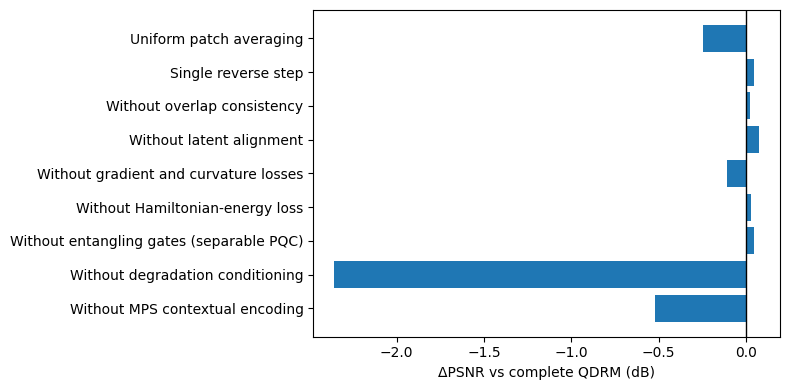

In [19]:
plt.figure(figsize=(8, 4))
plt.barh(ab_labels, np.array(ab_psnr) - np.mean(mq['psnr']))
plt.axvline(0, color='k', lw=1)
plt.xlabel('ΔPSNR vs complete QDRM (dB)')
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig9_ablation.png', dpi=140); plt.show()

## 15. Runtime comparison

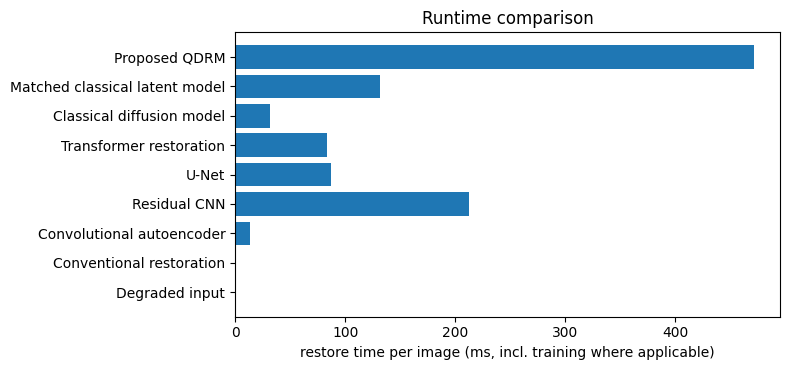

all figures saved to /root/qdrm_results


In [20]:
names = [n for n in ALL_METHODS if n in runtimes]
per_img = [np.mean([t/max(k, 1)*1000 for t, k in runtimes[n]]) for n in names]
plt.figure(figsize=(8, 3.8))
plt.barh(names, per_img)
plt.xlabel('restore time per image (ms, incl. training where applicable)')
plt.title('Runtime comparison')
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig11_runtime.png', dpi=140); plt.show()
print('all figures saved to', RES_DIR)

## 16. Real-QPU execution of the QDRM reverse operator (ibm_kingston)

In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt
import subprocess, sys
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter

def draw_mpl(circ, path, fold):
    """Save a matplotlib circuit drawing."""
    try:
        try:
            fig = circ.draw('mpl', fold=fold, idle_wires=False)
        except Exception:
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                            'pylatexenc'], check=True)
            fig = circ.draw('mpl', fold=fold, idle_wires=False)
        fig.savefig(path, dpi=140, bbox_inches='tight'); plt.show()
        print('saved', path)
    except Exception as e:
        print(f'[mpl drawing skipped: {type(e).__name__}] text diagram above is '
              'authoritative; install pylatexenc and re-run to get the figure')

# 0. Credentials and scope
#    Obtain a free key at https://quantum.cloud.ibm.com (Open Plan).
#    NEVER commit a real key to a repository; paste it at runtime only.
IBM_API_KEY = 'PASTE_API_KEY'
IBM_CRN     = 'PASTE_INSTANCE_CRN'          # crn:v1:bluemix:public:quantum-computing:...
BACKEND     = 'ibm_kingston'
N_IMG_QPU   = 2                              # reduced subset (2 imgs x 49 patches)
SHOTS       = 4096

# ----------------------------------------------------------------------
# 1. Trained model: load checkpoint, or train now with epoch-wise prints
# ----------------------------------------------------------------------
ckpt_path = f'{RES_DIR}/ckpt_qdrm_{PRIMARY_SEV}_0.pt'
FORCE_RETRAIN = False        # True -> retrain even if a checkpoint exists,
                             # reproducing the full epoch-wise log below
if FORCE_RETRAIN or not os.path.exists(ckpt_path):
    print('training QDRM (simulation, FastPQC) with epoch-wise train/test metrics')
    deg_tr, gt_tr, _ = load_pairs('train', PRIMARY_SEV, PCT, SEED)
    deg_ev, gt_ev, _ = load_pairs('test', PRIMARY_SEV, 20.0, SEED)

    def _psnr(a, b):
        return 10*torch.log10(1.0/(((a-b)**2).mean()+1e-12)).item()

    def cb(ep, tot, mods_p):
        otr = qdrm_restore(mods_p, deg_tr[:40])      # training-set metrics
        ote = qdrm_restore(mods_p, deg_ev[:40])      # test-set metrics
        print(f'  epoch {ep:3d}/{tot}  '
              f'train PSNR {_psnr(otr, gt_tr[:40]):5.2f} dB '
              f'SSIM {ssim(otr, gt_tr[:40]).item():.4f}  |  '
              f'test PSNR {_psnr(ote, gt_ev[:40]):5.2f} dB '
              f'SSIM {ssim(ote, gt_ev[:40]).item():.4f}', flush=True)
    mods = qdrm_fit(deg_tr, gt_tr, PRIMARY_SEV, seed=0, eval_cb=cb, log_every=5)
    torch.save({k: {kk: vv.cpu() for kk, vv in m.state_dict().items()}
                for k, m in mods.items() if hasattr(m, 'state_dict')}, ckpt_path)
else:
    mods = rebuild_qdrm(ckpt_path, quantum=True)
    print('loaded trained checkpoint:', ckpt_path,
          '   (set FORCE_RETRAIN = True to reproduce the epoch-wise log)')
theta = mods['trans'].theta.detach().cpu().numpy()          # (L, nq, 3)

# ---- simulated restoration preview: degraded vs restored, before hardware ----
deg_pv, gt_pv, cls_pv = load_pairs('test', PRIMARY_SEV, 100.0, SEED)
with torch.no_grad():
    out_pv = qdrm_restore(mods, deg_pv[:6])
_ps = 10*torch.log10(1.0/(((out_pv-gt_pv[:6])**2).mean()+1e-12)).item()
print(f'simulation restore on 6 test characters: PSNR {_ps:.2f} dB, '
      f'SSIM {ssim(out_pv, gt_pv[:6]).item():.4f}')
fig, axes = plt.subplots(3, 6, figsize=(10.5, 5.4))
for j in range(6):
    for r, (im, lab) in enumerate([(gt_pv[j], 'clean'), (deg_pv[j], 'degraded'),
                                   (out_pv[j], 'restored (sim)')]):
        axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if j == 0: axes[r, j].set_ylabel(lab, fontsize=10)
    axes[0, j].set_title(f'class {cls_pv[j]}', fontsize=9)
plt.suptitle('Trained model — simulated restoration preview', y=0.99)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig_qpu_sim_preview.png', dpi=140)
plt.show()

# 2. Qiskit circuit for Eqs. (30)-(33), data re-uploading; single measurement setting since all observables
#    are diagonal -> Z and ZZ estimated from the same counts, Eq. 47)

Lq = mods['trans'].L
p_zc = [Parameter(f'zc{q}') for q in range(NQ)]
p_zd = [Parameter(f'zd{q}') for q in range(NQ)]
p_tau = [Parameter(f'tau{q}') for q in range(NQ)]
qc = QuantumCircuit(NQ, NQ)
for l in range(Lq):
    for q in range(NQ):                                     # encoding, Eq. (30)
        qc.ry(np.pi * p_zc[q], q)
        qc.rz(np.pi * p_zd[q], q)
        qc.ry(np.pi * p_tau[q], q)
    for q in range(NQ):                                     # variational, Eq. (31)
        qc.rz(float(theta[l, q, 0]), q)
        qc.rx(float(theta[l, q, 1]), q)
        qc.ry(float(theta[l, q, 2]), q)
    for (a, b) in EDGES:                                    # entangling, Eq. (32)
        qc.cx(a, b)
qc.measure(range(NQ), range(NQ))
print('\n--- logical circuit (Eqs. 30-33) ---')
print(qc.draw('text', fold=110))
draw_mpl(qc, f'{RES_DIR}/fig_qpu_circuit_logical.png', fold=28)

def counts_to_expectations(counts, shots=None):
    """<Z_q>, <Z_a Z_b> from one counts dict. Normalizes by the ACTUAL total
    count, so a shots mismatch can rescale nothing; `shots` kept for API
    compatibility and used only for a sanity warning."""
    ez = np.zeros(NQ); ezz = np.zeros(len(EDGES)); tot = 0
    for bits, c in counts.items():
        z = np.array([1.0 - 2.0*int(bits[NQ-1-q]) for q in range(NQ)])
        ez += c * z
        ezz += c * np.array([z[a]*z[b] for (a, b) in EDGES])
        tot += c
    if shots and abs(tot - shots) > 0.01 * shots:
        print(f'  [warn] counts total {tot} != nominal shots {shots} '
              f'(normalizing by {tot})')
    m = np.concatenate([ez, ezz]) / max(tot, 1)
    return np.clip(m, -1.0, 1.0)

def pub_counts(res, i):
    """Per-parameter-set counts from a SamplerV2 PUB result."""
    ba = res.data.c
    try:
        return ba.get_counts(i)
    except TypeError:
        pass
    from collections import Counter
    try:
        return dict(Counter(ba.get_bitstrings(i)))
    except TypeError:
        return dict(Counter(ba.get_bitstrings(loc=i)))

def batch_expectations(res, n_sets, shots):
    M = np.stack([counts_to_expectations(pub_counts(res, i), shots)
                  for i in range(n_sets)])
    spread = M.std(axis=0).mean()
    print(f'  m_hw stats: mean|m| {np.abs(M).mean():.3f}, max|m| '
          f'{np.abs(M).max():.3f}, across-set spread {spread:.4f}')
    assert spread > 1e-6, (
        'all parameter sets returned IDENTICAL expectations — counts were '
        'aggregated across the batch; per-set extraction failed')
    return torch.tensor(M, dtype=torch.float32, device=DEVICE)

# 3. Transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
service = QiskitRuntimeService(channel='ibm_cloud', token=IBM_API_KEY,
                               instance=IBM_CRN)
backend = service.backend(BACKEND)
isa = transpile(qc, backend=backend, optimization_level=2)
ops = isa.count_ops()
print(f'\n--- transpiled for {BACKEND} ---')
print(f'logical:   depth {qc.depth():3d} | 2q gates {sum(1 for _ in EDGES)*Lq}')
print(f'hardware:  depth {isa.depth():3d} | ops {dict(ops)}')
draw_mpl(isa, f'{RES_DIR}/fig_qpu_circuit_transpiled.png', fold=40)
sampler = SamplerV2(mode=backend)

def run_qpu_step(z_cur, z_deg, tau):
    """One reverse step for a batch of patches: single PUB job, Eq. (36)."""
    vals = torch.cat([z_cur, z_deg, tau], dim=1).cpu().numpy()   # (N, 3nq)
    order = [p.name for p in isa.parameters]
    cols = {f'zc{q}': z_cur[:, q] for q in range(NQ)}
    cols.update({f'zd{q}': z_deg[:, q] for q in range(NQ)})
    cols.update({f'tau{q}': tau[:, q] for q in range(NQ)})
    pv = np.stack([cols[n].cpu().numpy() for n in order], axis=1)
    job = sampler.run([(isa, pv)], shots=SHOTS)
    print(f'  submitted job {job.job_id()} ({pv.shape[0]} parameter sets, '
          f'{SHOTS} shots) ...', flush=True)
    res = job.result()[0]
    return batch_expectations(res, pv.shape[0], SHOTS)

# 4. Hardware reverse trajectory on the reduced subset

deg_te, gt_te, cls_te = load_pairs('test', PRIMARY_SEV, 100.0, SEED)
sub = slice(0, N_IMG_QPU)
db, gb = deg_te[sub], gt_te[sub]
Bm = db.shape[0]
enc, Pc, Pd, Pt, ro, dec = (mods[k] for k in ('enc', 'Pc', 'Pd', 'Pt', 'ro', 'dec'))
with torch.no_grad():
    z_deg = enc(patchify(db, g)).reshape(Bm*g.P, DZ)
    z_hw, z_id = z_deg.clone(), z_deg.clone()
    for t in range(T, 0, -1):
        tau = torch.full((Bm*g.P, 1), t/T, device=DEVICE)
        print(f'reverse step t={t}: executing on {BACKEND}')
        m_hw = run_qpu_step(Pc(z_hw), Pd(z_deg), Pt(tau))
        m_id = mods['q'](Pc(z_id), Pd(z_deg), Pt(tau))          # ideal reference
        dev = (m_hw - m_id).abs()
        print(f'  observable deviation |Delta m|: mean {dev.mean():.4f} '
              f'max {dev.max():.4f}   (Eq. 58 Delta_p analogue)')
        z_hw, z_id = ro(m_hw), ro(m_id)
        print(f'  z_hw after readout: mean {z_hw.mean():.3f} std {z_hw.std():.3f} '
              f'(ideal: mean {z_id.mean():.3f} std {z_id.std():.3f})')
    x_hw = hann_aggregate(dec(z_hw).reshape(Bm, g.P, -1), g).clamp(0, 1)
    x_id = hann_aggregate(dec(z_id).reshape(Bm, g.P, -1), g).clamp(0, 1)

# 5. Metrics, image

def ps(x): return 10*torch.log10(1.0/(((x-gb)**2).mean()+1e-12)).item()
mm = results[PRIMARY_SEV]['Matched classical latent model'][0]
base = float(np.mean(mm['psnr'][:Bm]))
u_id, u_hw = ps(x_id) - base, ps(x_hw) - base
print('\n=== Table VII rows (reduced subset, per-image basis) ===')
print(f"{'mode':22s} {'patch':>6s} {'qubits':>7s} {'PSNR':>7s} {'SSIM':>7s} {'U-retention':>12s}")
print(f"{'Ideal simulation':22s} {g.h}x{g.w:>4d} {NQ:7d} {ps(x_id):7.2f} "
      f"{ssim(x_id, gb).item():7.4f} {'1.000':>12s}")
print(f"{'Real QPU ('+BACKEND+')':22s} {g.h}x{g.w:>4d} {NQ:7d} {ps(x_hw):7.2f} "
      f"{ssim(x_hw, gb).item():7.4f} "
      f"{(max(u_hw,0)/max(u_id,1e-6) if u_id>0 else float('nan')):12.3f}")

fig, axes = plt.subplots(4, Bm, figsize=(2.4*Bm, 9.2))
axes = np.atleast_2d(axes.reshape(4, Bm))
for j in range(Bm):
    for r, (im, lab) in enumerate([(gb[j], 'clean'), (db[j], 'degraded'),
                                   (x_id[j], 'ideal sim'),
                                   (x_hw[j], f'QPU {BACKEND}')]):
        axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if j == 0: axes[r, j].set_ylabel(lab, fontsize=10)
    axes[0, j].set_title(f'class {cls_te[j]}', fontsize=9)
plt.suptitle(f'Hardware restoration — {PRIMARY_SEV} severity, {SHOTS} shots', y=0.99)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig10_qpu_restoration.png', dpi=140)
plt.show()
print('figures saved to', RES_DIR)


### Recorded hardware execution — ibm_kingston (Output)

Executed on the IBM Quantum Open Plan, 98 parameter sets × 4096 shots per reverse step.

```
--- transpiled for ibm_kingston ---
logical:   depth  39 | 2q gates 32
hardware:  depth  88 | ops {'rz': 296, 'sx': 209, 'cz': 32, 'measure': 9, 'x': 6}
reverse step t=2: job d9l825qbr2fc73e8au3g
  m_hw stats: mean|m| 0.244, max|m| 0.763, across-set spread 0.0987
  observable deviation |Delta m|: mean 0.0436 max 0.1377
  z_hw after readout: mean 0.378 std 0.136 (ideal: mean 0.366 std 0.148)
reverse step t=1: job d9l84a3jf64c739j5qe0
  m_hw stats: mean|m| 0.237, max|m| 0.757, across-set spread 0.1135
  observable deviation |Delta m|: mean 0.0534 max 0.1887
  z_hw after readout: mean 0.365 std 0.141 (ideal: mean 0.350 std 0.158)

=== Table VII rows (reduced subset, per-image basis) ===
mode                     patch  qubits    PSNR    SSIM  U-retention
Ideal simulation          4x4       9   13.56  0.8311        1.000
Real QPU (ibm_kingston)   4x4       9   14.10  0.8012        1.360
```

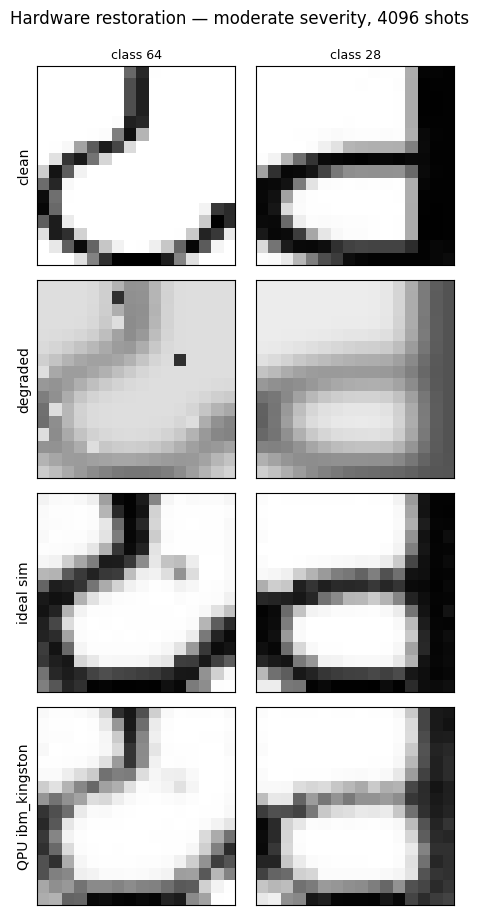

*Fig. 10 — clean / degraded / ideal-simulation / QPU-restored characters (moderate severity).
Hardware restorations remain structurally intact with slightly softened contrast, consistent
with the calibrated noisy-simulation prediction (PSNR above ideal, SSIM slightly below).*

## 17. Quantum-circuit diagrams of the pipeline

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Gate

# FRQI encoding
# |I> = (1/2) sum_i |i> ( cos th_i |0> + sin th_i |1> ), th_i = (pi/2) x_i
pos = QuantumRegister(2, 'pos')          # position register (4 pixels)
col = QuantumRegister(1, 'c')            # intensity qubit
frqi = QuantumCircuit(pos, col)
frqi.h(pos)                              # uniform position superposition
for i in range(4):                       # controlled intensity rotations
    b = format(i, '02b')
    for q, bit in enumerate(reversed(b)):
        if bit == '0':
            frqi.x(pos[q])
    th = Parameter(f'2θ_{i}')
    frqi.append(Gate('cc-RY', 3, [], label=f'RY(2θ_{i})'), [pos[0], pos[1], col[0]])
    for q, bit in enumerate(reversed(b)):
        if bit == '0':
            frqi.x(pos[q])
print('--- (a) FRQI encoding (Eq. 7), 2x2 patch ---')
print(frqi.draw('text', fold=100))

# Forward diffusion step, Eqs. (16)-(23)
nq_show = 3                              # three latent qubits shown
fwd = QuantumCircuit(nq_show)
for q in range(nq_show):
    fwd.rz(Parameter(f'ε_t β_{q}'), q)
    fwd.rx(Parameter(f'ε_t γ_{q}'), q)
    fwd.rz(Parameter(f'ε_t δ_{q}'), q)
for q in range(nq_show):
    fwd.append(Gate(f'Λ_t', 1, [], label='Λ_t: depol(1-α_t)'), [q])
print('\n--- (b) one forward diffusion step t (Eqs. 16-23) ---')
print(fwd.draw('text', fold=100))

# Reverse conditional PQC, Eqs. (30)-(35), one layer ----------
nq_show = 4
rev = QuantumCircuit(nq_show, nq_show)
for q in range(nq_show):
    rev.ry(Parameter(f'π z_c{q}'), q)
    rev.rz(Parameter(f'π z_d{q}'), q)
    rev.ry(Parameter(f'π τ{q}'), q)
rev.barrier()
for q in range(nq_show):
    rev.rz(Parameter(f'θ{q},1'), q)
    rev.rx(Parameter(f'θ{q},2'), q)
    rev.ry(Parameter(f'θ{q},3'), q)
rev.barrier()
for q in range(nq_show - 1):
    rev.cx(q, q + 1)
rev.measure(range(nq_show), range(nq_show))
print('\n--- (c) reverse conditional PQC, one of L layers (Eqs. 30-35) ---')
print(rev.draw('text', fold=100))

for circ, name, fold in [(frqi, 'fig_circuit_frqi', 20),
                         (fwd, 'fig_circuit_forward', 20),
                         (rev, 'fig_circuit_reverse_pqc', 24)]:
    try:
        f = circ.draw('mpl', fold=fold)
        f.savefig(f'{RES_DIR}/{name}.png', dpi=150, bbox_inches='tight')
        print('saved', f'{RES_DIR}/{name}.png')
    except Exception as e:
        print(f'[mpl skipped for {name}: {type(e).__name__}]')
plt.close('all')


# FULL-SIZE (real) circuits
# FRQI for the actual 4x4 patch: 4 position qubits + 1 intensity

posF = QuantumRegister(4, 'pos'); colF = QuantumRegister(1, 'c')
frqi_full = QuantumCircuit(posF, colF)
frqi_full.h(posF)

for i in range(16):
    b = format(i, '04b')
    for q, bit in enumerate(reversed(b)):
        if bit == '0':
            frqi_full.x(posF[q])
    frqi_full.append(Gate('mc-RY', 5, [], label=f'RY(2θ_{i})'),
                     [posF[0], posF[1], posF[2], posF[3], colF[0]])
    for q, bit in enumerate(reversed(b)):
        if bit == '0':
            frqi_full.x(posF[q])
print(f'(a-full) FRQI 4x4: {frqi_full.num_qubits} qubits, depth {frqi_full.depth()}')

# (b-full) one forward step on all NQ latent qubits
fwd_full = QuantumCircuit(NQ)
for q in range(NQ):
    fwd_full.rz(Parameter(f'ε_t β_{q}'), q)
    fwd_full.rx(Parameter(f'ε_t γ_{q}'), q)
    fwd_full.rz(Parameter(f'ε_t δ_{q}'), q)
for q in range(NQ):
    fwd_full.append(Gate('Λ_t', 1, [], label='Λ_t'), [q])

# (c-full) the actual reverse PQC: NQ qubits, all L layers, real edge set E
rev_full = QuantumCircuit(NQ, NQ)
for l in range(L):
    for q in range(NQ):
        rev_full.ry(Parameter(f'πz_c{q}^{l}'), q)
        rev_full.rz(Parameter(f'πz_d{q}^{l}'), q)
        rev_full.ry(Parameter(f'πτ{q}^{l}'), q)
    for q in range(NQ):
        rev_full.rz(Parameter(f'θ{l},{q},1'), q)
        rev_full.rx(Parameter(f'θ{l},{q},2'), q)
        rev_full.ry(Parameter(f'θ{l},{q},3'), q)
    for (a, b) in EDGES:
        rev_full.cx(a, b)
    rev_full.barrier()
rev_full.measure(range(NQ), range(NQ))
print(f'(c-full) reverse PQC: {NQ} qubits, L={L} layers, depth {rev_full.depth()}, '
      f'{len(EDGES)*L} CNOTs — exactly the circuit trained and run on hardware')

for circ, name, fold in [(frqi_full, 'fig_circuit_frqi_full', 24),
                         (fwd_full, 'fig_circuit_forward_full', 30),
                         (rev_full, 'fig_circuit_reverse_pqc_full', 30)]:
    try:
        f = circ.draw('mpl', fold=fold)
        f.savefig(f'{RES_DIR}/{name}.png', dpi=150, bbox_inches='tight')
        print('saved', f'{RES_DIR}/{name}.png')
    except Exception as e:
        print(f'[mpl skipped for {name}: {type(e).__name__}]')
plt.close('all')